In [950]:
import pandas as pd
import numpy as np

### Importation des fichiers de données et transformation en dataframe

In [951]:
from pathlib import Path

# On part du dossier où se trouve le notebook, puis on remonte d'un niveau pour atteindre la racine du projet.
root_path = Path.cwd().parent 

# 2. Définir le chemin vers le dossier des données
data_folder = root_path / "data/raws"

print(f"🔍 Recherche des données dans : {data_folder}")

# 3. Créer un dictionnaire pour stocker nos DataFrames
# Clé = nom du fichier, Valeur = DataFrame chargé
all_dataframes = {}

# 4. Vérifier si le dossier existe
if data_folder.exists() and data_folder.is_dir():
    
    # On cherche tous les fichiers finissant par .csv dans le dossier data
    csv_files = list(data_folder.glob("*.csv"))
    
    if not csv_files:
        print("⚠️ Aucun fichier CSV trouvé dans le dossier 'data'.")
    else:
        print(f"✅ {len(csv_files)} fichiers trouvés. Chargement en cours...")
        
        for file_path in csv_files:
            try:
                # On utilise le nom du fichier (sans l'extension) comme clé
                df_name = file_path.stem 
                
                # Chargement du CSV
                df = pd.read_csv(file_path)
                
                # Stockage dans notre dictionnaire
                all_dataframes[df_name] = df
                
                print(f"   👉 {file_path.name} chargé ({len(df)} lignes)")
                
            except Exception as e:
                print(f"   ❌ Erreur sur {file_path.name} : {e}")
                
        print("\n✨ Chargement terminé !")
else:
    print(f"❌ Le dossier '{data_folder}' est introuvable. Vérifie ton arborescence.")


🔍 Recherche des données dans : c:\Users\johan\VS Code Wild 2\BRIEF_FAO_DataLab_Analyse_mondiale_de_la_sécurité_alimentaire\data\raws
✅ 5 fichiers trouvés. Chargement en cours...
   👉 fr_animaux.csv chargé (37166 lignes)
   👉 fr_céréales.csv chargé (891 lignes)
   👉 fr_population.csv chargé (175 lignes)
   👉 fr_sousalimentation.csv chargé (1020 lignes)
   👉 fr_vegetaux.csv chargé (104871 lignes)

✨ Chargement terminé !


### Analyse descriptive

In [952]:
print("👀 Inspection visuelle des premières lignes\n")
print("=" * 60)

for name, df in all_dataframes.items():
    print(f"📂 FICHIER : {name}")
    print(f"📏 Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    print("-" * 30)
    
    # Affichage des 5 premières lignes
    # On utilise display() pour une belle présentation dans le notebook
    display(df.head(10))
    
    print("\n" + "=" * 60 + "\n")

👀 Inspection visuelle des premières lignes

📂 FICHIER : fr_animaux
📏 Dimensions : 37166 lignes, 14 colonnes
------------------------------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2731,Viande de Bovins,2013,2013,Milliers de tonnes,134.00,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2731,Viande de Bovins,2013,2013,Milliers de tonnes,6.00,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2731,Viande de Bovins,2013,2013,Milliers de tonnes,140.00,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5142,Nourriture,2731,Viande de Bovins,2013,2013,Milliers de tonnes,140.00,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,2731,Viande de Bovins,2013,2013,kg,4.59,Fc,Donnée calculée
5,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,664,Disponibilité alimentaire (Kcal/personne/jour),2731,Viande de Bovins,2013,2013,Kcal/personne/jour,27.00,Fc,Donnée calculée
6,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,674,Disponibilité de protéines en quantité (g/pers...,2731,Viande de Bovins,2013,2013,g/personne/jour,1.89,Fc,Donnée calculée
7,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,684,Disponibilité de matière grasse en quantité (g...,2731,Viande de Bovins,2013,2013,g/personne/jour,2.10,Fc,Donnée calculée
8,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2732,Viande d'Ovins/Caprins,2013,2013,Milliers de tonnes,150.00,S,Données standardisées
9,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2732,Viande d'Ovins/Caprins,2013,2013,Milliers de tonnes,150.00,S,Données standardisées




📂 FICHIER : fr_céréales
📏 Dimensions : 891 lignes, 14 colonnes
------------------------------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2805,Riz (Eq Blanchi),2013,2013,Milliers de tonnes,342,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2513,Orge,2013,2013,Milliers de tonnes,514,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2514,Maïs,2013,2013,Milliers de tonnes,312,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2517,Millet,2013,2013,Milliers de tonnes,13,S,Données standardisées
5,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,1870,S,Données standardisées
6,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,5511,Production,2805,Riz (Eq Blanchi),2013,2013,Milliers de tonnes,3,S,Données standardisées
7,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,5511,Production,2513,Orge,2013,2013,Milliers de tonnes,268,S,Données standardisées
8,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,5511,Production,2514,Maïs,2013,2013,Milliers de tonnes,11811,S,Données standardisées
9,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,5511,Production,2515,Seigle,2013,2013,Milliers de tonnes,2,S,Données standardisées




📂 FICHIER : fr_population
📏 Dimensions : 175 lignes, 14 colonnes
------------------------------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,511,Population totale,2501,Population,2013,2013,1000 personnes,30552,NaN,Donnée officielle
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,511,Population totale,2501,Population,2013,2013,1000 personnes,52776,NaN,Donnée officielle
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,3,Albanie,511,Population totale,2501,Population,2013,2013,1000 personnes,3173,NaN,Donnée officielle
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,4,Algérie,511,Population totale,2501,Population,2013,2013,1000 personnes,39208,NaN,Donnée officielle
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,79,Allemagne,511,Population totale,2501,Population,2013,2013,1000 personnes,82727,NaN,Donnée officielle
5,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,7,Angola,511,Population totale,2501,Population,2013,2013,1000 personnes,21472,NaN,Donnée officielle
6,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,8,Antigua-et-Barbuda,511,Population totale,2501,Population,2013,2013,1000 personnes,90,NaN,Donnée officielle
7,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,194,Arabie saoudite,511,Population totale,2501,Population,2013,2013,1000 personnes,28829,NaN,Donnée officielle
8,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,9,Argentine,511,Population totale,2501,Population,2013,2013,1000 personnes,41446,NaN,Donnée officielle
9,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,1,Arménie,511,Population totale,2501,Population,2013,2013,1000 personnes,2977,NaN,Donnée officielle




📂 FICHIER : fr_sousalimentation
📏 Dimensions : 1020 lignes, 15 colonnes
------------------------------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,7.9,F,Estimation FAO,NaN
1,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,8.8,F,Estimation FAO,NaN
2,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,9.6,F,Estimation FAO,NaN
3,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,10.2,F,Estimation FAO,NaN
4,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20162018,2016-2018,millions,10.6,F,Estimation FAO,NaN
5,FS,Données de la sécurité alimentaire,202,Afrique du Sud,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,2.6,F,Estimation FAO,NaN
6,FS,Données de la sécurité alimentaire,202,Afrique du Sud,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,2.8,F,Estimation FAO,NaN
7,FS,Données de la sécurité alimentaire,202,Afrique du Sud,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,3.2,F,Estimation FAO,NaN
8,FS,Données de la sécurité alimentaire,202,Afrique du Sud,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,3.4,F,Estimation FAO,NaN
9,FS,Données de la sécurité alimentaire,202,Afrique du Sud,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20162018,2016-2018,millions,3.5,F,Estimation FAO,NaN




📂 FICHIER : fr_vegetaux
📏 Dimensions : 104871 lignes, 14 colonnes
------------------------------


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169.00,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2511,Blé,2013,2013,Milliers de tonnes,1173.00,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5072,Variation de stock,2511,Blé,2013,2013,Milliers de tonnes,-350.00,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé,2013,2013,Milliers de tonnes,5992.00,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5527,Semences,2511,Blé,2013,2013,Milliers de tonnes,322.00,S,Données standardisées
5,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5123,Pertes,2511,Blé,2013,2013,Milliers de tonnes,775.00,S,Données standardisées
6,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5142,Nourriture,2511,Blé,2013,2013,Milliers de tonnes,4895.00,S,Données standardisées
7,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,2511,Blé,2013,2013,kg,160.23,Fc,Donnée calculée
8,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,664,Disponibilité alimentaire (Kcal/personne/jour),2511,Blé,2013,2013,Kcal/personne/jour,1369.00,Fc,Donnée calculée
9,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,674,Disponibilité de protéines en quantité (g/pers...,2511,Blé,2013,2013,g/personne/jour,36.91,Fc,Donnée calculée


In [953]:
print("🔍 Rapport de Qualité des Données (Taux de complétude)\n")
print("-" * 60)

# On parcourt notre dictionnaire de DataFrames
for name, df in all_dataframes.items():
    total_rows = len(df)
    
    print(f"📊 FICHIER : {name} ({total_rows} lignes)")
    print("-" * 30)
    
    # On calcule les valeurs manquantes pour chaque colonne
    null_counts = df.isnull().sum()
    
    for col in null_counts.index:
        null_count = null_counts[col]
        
        if total_rows > 0:
            # Calcul du pourcentage de données manquantes
            pct_missing = (null_count / total_rows) * 100
            
            # On prépare un affichage propre
            # Si le manque est faible, on affiche en vert (symboliquement)
            # Si le manque est élevé (> 5%), on l'alerte
            status = "✅ OK" if pct_missing < 5 else "⚠️ ALERTE"
            
            print(f"  [{status}] {col:20} : {null_count:>6} manquantes ({pct_missing:>5.2f}%)")
        else:
            print((f"  ❌ Fichier vide pour la colonne {col}"))
            
    print("\n" + "="*60 + "\n")

🔍 Rapport de Qualité des Données (Taux de complétude)

------------------------------------------------------------
📊 FICHIER : fr_animaux (37166 lignes)
------------------------------
  [✅ OK] Code Domaine         :      0 manquantes ( 0.00%)
  [✅ OK] Domaine              :      0 manquantes ( 0.00%)
  [✅ OK] Code zone            :      0 manquantes ( 0.00%)
  [✅ OK] Zone                 :      0 manquantes ( 0.00%)
  [✅ OK] Code Élément         :      0 manquantes ( 0.00%)
  [✅ OK] Élément              :      0 manquantes ( 0.00%)
  [✅ OK] Code Produit         :      0 manquantes ( 0.00%)
  [✅ OK] Produit              :      0 manquantes ( 0.00%)
  [✅ OK] Code année           :      0 manquantes ( 0.00%)
  [✅ OK] Année                :      0 manquantes ( 0.00%)
  [✅ OK] Unité                :      0 manquantes ( 0.00%)
  [✅ OK] Valeur               :      0 manquantes ( 0.00%)
  [✅ OK] Symbole              :      0 manquantes ( 0.00%)
  [✅ OK] Description du Symbole :      0 manquan

Certaines colonnes sont très peu remplies voire complètement vides.  
Je supprimerai les colonnes 'symbole' de fr_population et 'note' de fr_sousalimentation.  
j'investiguerai sur la colonne 'Valeur' de fr_sousalimentation pour juger de l'intéret de cette colonne qui présente 40% de valeurs manquantes.

In [954]:
print("🔍 Rapport de Qualité des Données (Doublons)\n")
print("-" * 60)

for name, df in all_dataframes.items():
    total_rows = len(df)
    
    # --- PARTIE 1 : Vérification des doublons parfaits ---
    duplicate_count = df.duplicated().sum()
    
    print(f"📊 FICHIER : {name} ({total_rows} lignes)")
    print(f"  [!] Doublons parfaits trouvés : {duplicate_count}")

🔍 Rapport de Qualité des Données (Doublons)

------------------------------------------------------------
📊 FICHIER : fr_animaux (37166 lignes)
  [!] Doublons parfaits trouvés : 0
📊 FICHIER : fr_céréales (891 lignes)
  [!] Doublons parfaits trouvés : 0
📊 FICHIER : fr_population (175 lignes)
  [!] Doublons parfaits trouvés : 0
📊 FICHIER : fr_sousalimentation (1020 lignes)
  [!] Doublons parfaits trouvés : 0
📊 FICHIER : fr_vegetaux (104871 lignes)
  [!] Doublons parfaits trouvés : 0


Aucun doublon parfait  
En fonction des données regardées, nous analyserons plus en détail les éventuelles lignes doublées partiellement

In [955]:
print("🔍 Rapport de Qualité des Données (Dtypes)\n")
print("-" * 60)

for name, df in all_dataframes.items():
    print(f"📊 FICHIER : {name}")
    print(f"  Total colonnes : {len(df.columns)}")
    print("-" * 30)
    
    # On récupère les types et on crée un petit tableau récapitulatif
    dtype_info = []
    for col, dtype in df.dtypes.items():
        # On compte combien de valeurs ne sont PAS nulles pour voir la réalité du type
        non_null_count = df[col].count()
        dtype_info.append({
            "Colonne": col,
            "Type actuel": dtype,
  			"Valeurs non-nulles": non_null_count
        })
    
    # Création d'un DataFrame de diagnostic pour un affichage propre
    df_diag = pd.DataFrame(dtype_info)
    
    # On affiche le tableau de diagnostic
    display(df_diag)
    
    # Alerte spécifique : On cherche les colonnes numériques qui sont en type 'object'
    # (C'est souvent là que se cachent les erreurs de lecture)
    numeric_as_object = df_diag[(df_diag['Type actuel'] == 'object') & 
                                (df_diag['Colonne'].str.contains('Valeur|Année|Code', case=False, na=False))]
    
    if not numeric_as_object.empty:
        print(f"  ⚠️ ALERTE : Colonnes numériques potentiellement mal typées :")
        for _, row in numeric_as_object.iterrows():
            print(f"     👉 {row['Colonne']} est en type '{row['Type actuel']}'")
    else:
        print("  ✅ Aucun problème de type numérique détecté.")
        
    print("\n" + "="*60 + "\n")

🔍 Rapport de Qualité des Données (Dtypes)

------------------------------------------------------------
📊 FICHIER : fr_animaux
  Total colonnes : 14
------------------------------


,Colonne,Type actuel,Valeurs non-nulles
0,Code Domaine,str,37166
1,Domaine,str,37166
2,Code zone,int64,37166
3,Zone,str,37166
4,Code Élément,int64,37166
5,Élément,str,37166
6,Code Produit,int64,37166
7,Produit,str,37166
8,Code année,int64,37166
9,Année,int64,37166


  ✅ Aucun problème de type numérique détecté.


📊 FICHIER : fr_céréales
  Total colonnes : 14
------------------------------


,Colonne,Type actuel,Valeurs non-nulles
0,Code Domaine,str,891
1,Domaine,str,891
2,Code zone,int64,891
3,Zone,str,891
4,Code Élément,int64,891
5,Élément,str,891
6,Code Produit,int64,891
7,Produit,str,891
8,Code année,int64,891
9,Année,int64,891


  ✅ Aucun problème de type numérique détecté.


📊 FICHIER : fr_population
  Total colonnes : 14
------------------------------


...

  ✅ Aucun problème de type numérique détecté.


📊 FICHIER : fr_sousalimentation
  Total colonnes : 15
------------------------------


,Colonne,Type actuel,Valeurs non-nulles
0,Code Domaine,str,1020
1,Domaine,str,1020
2,Code zone,int64,1020
3,Zone,str,1020
4,Code Élément,int64,1020
5,Élément,str,1020
6,Code Produit,int64,1020
7,Produit,str,1020
8,Code année,int64,1020
9,Année,str,1020


  ✅ Aucun problème de type numérique détecté.


📊 FICHIER : fr_vegetaux
  Total colonnes : 14
------------------------------


,Colonne,Type actuel,Valeurs non-nulles
0,Code Domaine,str,104871
1,Domaine,str,104871
2,Code zone,int64,104871
3,Zone,str,104871
4,Code Élément,int64,104871
5,Élément,str,104871
6,Code Produit,int64,104871
7,Produit,str,104871
8,Code année,int64,104871
9,Année,int64,104871


  ✅ Aucun problème de type numérique détecté.




une erreur de type : la colonne 'Unité' de fr_sousalimentation est un str alors qu'elle devrait être un float

In [956]:
print("📊 Analyse descriptive des distributions\n")
print("=" * 60)

for name, df in all_dataframes.items():
    print(f"📂 FICHIER : {name}")
    print("-" * 30)
    
    # On sélectionne uniquement les colonnes numériques pour le describe
    df_numeric = df.select_dtypes(include=['number'])
    
    if df_numeric.empty:
        print("  ℹ️ Pas de colonnes numériques dans ce fichier.")
    else:
        # Le describe() avec les statistiques clés
        stats = df_numeric.describe().T  # .T pour transposer et avoir un tableau lisible
        
        # On ajoute la variance pour voir l'étalement des données
        stats['variance'] = df_numeric.var()
        
        # On affiche le résultat
        display(stats[['count', 'mean', 'std', 'variance', 'min', '50%', 'max']])
        
        print("\n  💡 Note d'analyse :")
        for col in df_numeric.columns:
            col_min = df_arg_min = df_numeric[col].min()
            col_max = df_numeric[col].max()
            col_mean = df_numeric[col].mean()
            
            # Si la moyenne est très loin de la médiane (50%), il y a un déséquilibre
            if abs(col_mean - df_numeric[col].median()) > (df_numeric[col].std() * 1):
                print(f"     ⚠️ Attention sur '{col}' : La moyenne et la médiane sont très décalées. Présence probable d'asymétrie.")

    print("\n" + "=" * 60 + "\n")

📊 Analyse descriptive des distributions

📂 FICHIER : fr_animaux
------------------------------


,count,mean,std,variance,min,50%,max
Code zone,37166.0,126.800839,74.767139,5.590125e+03,1.0,121.0,351.0
Code Élément,37166.0,3511.032718,2332.283315,5.439545e+06,645.0,5142.0,5911.0
Code Produit,37166.0,2758.421191,27.454449,7.537468e+02,2731.0,2762.0,2848.0
Code année,37166.0,2013.000000,0.000000,0.000000e+00,2013.0,2013.0,2013.0
Année,37166.0,2013.000000,0.000000,0.000000e+00,2013.0,2013.0,2013.0
Valeur,37166.0,148.291647,1933.728473,3.739306e+06,-1368.0,1.0,135600.0



  💡 Note d'analyse :


📂 FICHIER : fr_céréales
------------------------------


,count,mean,std,variance,min,50%,max
Code zone,891.0,130.005612,74.807040,5.596093e+03,1.0,129.0,276.0
Code Élément,891.0,5511.000000,0.000000,0.000000e+00,5511.0,5511.0,5511.0
Code Produit,891.0,2551.648709,96.152834,9.245367e+03,2511.0,2516.0,2805.0
Code année,891.0,2013.000000,0.000000,0.000000e+00,2013.0,2013.0,2013.0
Année,891.0,2013.000000,0.000000,0.000000e+00,2013.0,2013.0,2013.0
Valeur,891.0,2832.037037,16786.590126,2.817896e+08,0.0,95.0,353699.0



  💡 Note d'analyse :


📂 FICHIER : fr_population
------------------------------


...


  💡 Note d'analyse :


📂 FICHIER : fr_sousalimentation
------------------------------


,count,mean,std,variance,min,50%,max
Code zone,1020.0,1.292647e+02,76.615019,5.869861e+03,1.0,127.5,351.0
Code Élément,1020.0,6.132000e+03,0.000000,0.000000e+00,6132.0,6132.0,6132.0
Code Produit,1020.0,2.100110e+05,0.000000,0.000000e+00,210011.0,210011.0,210011.0
Code année,1020.0,2.014202e+07,14150.488052,2.002363e+08,20122014.0,20142016.0,20162018.0
Note,0.0,NaN,NaN,NaN,NaN,NaN,NaN



  💡 Note d'analyse :


📂 FICHIER : fr_vegetaux
------------------------------


,count,mean,std,variance,min,50%,max
Code zone,104871.0,127.694682,75.423255,5.688667e+03,1.0,121.0,351.0
Code Élément,104871.0,3728.248429,2276.474811,5.182338e+06,645.0,5142.0,5911.0
Code Produit,104871.0,2587.470998,61.107727,3.734154e+03,2511.0,2575.0,2899.0
Code année,104871.0,2013.000000,0.000000,0.000000e+00,2013.0,2013.0,2013.0
Année,104871.0,2013.000000,0.000000,0.000000e+00,2013.0,2013.0,2013.0
Valeur,104871.0,321.271016,6395.039684,4.089653e+07,-39863.0,1.0,739267.0



  💡 Note d'analyse :




fr_vegetaux contient des nombres négatifs dans la colonne 'valeur', il faut s'assurer de la vraisemblance de cette donnée.  
L'année de référence des données est 2013, les données de la sous-nutrition comprennent plusieurs périodes, il faudra être vigilent à ne récuperer que l'année 2013 pour faire des corrélations.

In [957]:
all_dataframes['fr_vegetaux'][(all_dataframes['fr_vegetaux']['Code zone'] == 2)].head(20)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169.00,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2511,Blé,2013,2013,Milliers de tonnes,1173.00,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5072,Variation de stock,2511,Blé,2013,2013,Milliers de tonnes,-350.00,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé,2013,2013,Milliers de tonnes,5992.00,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5527,Semences,2511,Blé,2013,2013,Milliers de tonnes,322.00,S,Données standardisées
5,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5123,Pertes,2511,Blé,2013,2013,Milliers de tonnes,775.00,S,Données standardisées
6,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5142,Nourriture,2511,Blé,2013,2013,Milliers de tonnes,4895.00,S,Données standardisées
7,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,2511,Blé,2013,2013,kg,160.23,Fc,Donnée calculée
8,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,664,Disponibilité alimentaire (Kcal/personne/jour),2511,Blé,2013,2013,Kcal/personne/jour,1369.00,Fc,Donnée calculée
9,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,674,Disponibilité de protéines en quantité (g/pers...,2511,Blé,2013,2013,g/personne/jour,36.91,Fc,Donnée calculée


In [958]:
# j'essaie d'avoir l'intitulé complet d'une colonne
all_dataframes['fr_vegetaux'][(all_dataframes['fr_vegetaux']['Code zone'] == 2)]['Élément'].values

<StringArray>
[                                                   'Production',
                                       'Importations - Quantité',
                                            'Variation de stock',
                                      'Disponibilité intérieure',
                                                      'Semences',
                                                        'Pertes',
                                                    'Nourriture',
        'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne/jour)',
      'Disponibilité de protéines en quantité (g/personne/jour)',
 ...
                                       'Importations - Quantité',
                                      'Disponibilité intérieure',
                                                    'Nourriture',
        'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne

376 lignes de données par pays concernant l'alimentation végétale, ce n'est pas exploitables en l'état, nous ne pouvons pas faire de statistiques sur autant de données à la fois et certaines données se recoupent probablement.  
ici on cherche plutot un global d'aliments, ressources végétale pour la population d'un pays, pas le détail de calories contenues dans un type d'aliment.  
les données qui semblent intéressantes sont :
['Production' , 'Importations - Quantité', 'Disponibilité intérieure', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)'] sous forme de total par pays

In [959]:
# je regarde les valeurs uniques de la colonne 'Élément' pour vérifier qu'il n'y a pas de fautes
elements_uniques = all_dataframes['fr_vegetaux']['Élément'].unique()

print(f"Nombre d'éléments uniques : {len(elements_uniques)}")
print("Liste des éléments :\n", elements_uniques)

Nombre d'éléments uniques : 15
Liste des éléments :
 <StringArray>
[                                                   'Production',
                                       'Importations - Quantité',
                                            'Variation de stock',
                                      'Disponibilité intérieure',
                                                      'Semences',
                                                        'Pertes',
                                                    'Nourriture',
        'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne/jour)',
      'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
                                         'Aliments pour animaux',
                                       'Exportations - Quantité',
                                                    'Traitement',
         

pas d'élément unique avec faute : OK  
  
Faisons la même chose avec le dataset fr_animaux

In [960]:
all_dataframes['fr_animaux'][(all_dataframes['fr_vegetaux']['Code zone'] == 2)].head(20)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2731,Viande de Bovins,2013,2013,Milliers de tonnes,134.00,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2731,Viande de Bovins,2013,2013,Milliers de tonnes,6.00,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2731,Viande de Bovins,2013,2013,Milliers de tonnes,140.00,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5142,Nourriture,2731,Viande de Bovins,2013,2013,Milliers de tonnes,140.00,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,2731,Viande de Bovins,2013,2013,kg,4.59,Fc,Donnée calculée
5,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,664,Disponibilité alimentaire (Kcal/personne/jour),2731,Viande de Bovins,2013,2013,Kcal/personne/jour,27.00,Fc,Donnée calculée
6,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,674,Disponibilité de protéines en quantité (g/pers...,2731,Viande de Bovins,2013,2013,g/personne/jour,1.89,Fc,Donnée calculée
7,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,684,Disponibilité de matière grasse en quantité (g...,2731,Viande de Bovins,2013,2013,g/personne/jour,2.10,Fc,Donnée calculée
8,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2732,Viande d'Ovins/Caprins,2013,2013,Milliers de tonnes,150.00,S,Données standardisées
9,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2732,Viande d'Ovins/Caprins,2013,2013,Milliers de tonnes,150.00,S,Données standardisées


In [961]:
# je regarde les valeurs uniques de la colonne 'Élément' pour vérifier qu'il n'y a pas de fautes
elements_uniques = all_dataframes['fr_animaux']['Élément'].unique()

print(f"Nombre d'éléments uniques : {len(elements_uniques)}")
print("Liste des éléments :\n", elements_uniques)

Nombre d'éléments uniques : 15
Liste des éléments :
 <StringArray>
[                                                   'Production',
                                       'Importations - Quantité',
                                      'Disponibilité intérieure',
                                                    'Nourriture',
        'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne/jour)',
      'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
                                                      'Semences',
                                                        'Pertes',
                                       'Exportations - Quantité',
                                         'Aliments pour animaux',
                         'Autres utilisations (non alimentaire)',
                                            'Variation de stock',
         

idem que fr_vegetaux : OK, pas d'anomalie  
fr_cereales est une sous_partie de fr_vegetaux : je ne le traite pas

In [962]:
# je vérifie l'existence des 15 lignes distinctes d'Element pour chaque 'Code Produit' dans fr_animaux et fr_vegetaux

print("🔍 Diagnostic détaillé des éléments manquants\n")
print("=" * 60)

def diagnose_missing_elements(df, df_name):
    if 'Élément' not in df.columns or 'Produit' not in df.columns or 'Code Produit' not in df.columns:
        return

    # On récupère la liste complète théorique des 15 éléments attendus
    total_expected = df['Élément'].nunique() 
    print(f"📊 Analyse sur {df_name} ({total_expected} éléments théoriques)")
    
    # On groupe par 'Code Produit' et on regarde quels éléments sont présents
    for prod_code, group_data in df.groupby('Code Produit'):
        
        # On récupère le nom du produit (on prend juste le premier trouvé)
        prod_name = group_data['Produit'].iloc[0]
        
        # On compare les éléments présents avec tous les éléments possibles du dataset
        present_elements = set(group_data['Élément'])
        all_elements = set(df['Élément'])
        
        missing_elements = list(all_elements - present_elements)
        
        if missing_elements:
            print(f"⚠️ Produit : {prod_name} (Code: {prod_code})")
            for el in missing_elements:
                print(f"   -> Élément manquant : {el}")
            print("-" * 40)

# Lancement du diagnostic sur tes fichiers principaux
diagnose_missing_elements(all_dataframes['fr_vegetaux'], 'fr_vegetaux.csv')
diagnose_missing_elements(all_dataframes['fr_animaux'], 'fr_animaux.csv')

🔍 Diagnostic détaillé des éléments manquants

📊 Analyse sur fr_vegetaux.csv (15 éléments théoriques)
⚠️ Produit : Ignames (Code: 2535)
   -> Élément manquant : Traitement
----------------------------------------
⚠️ Produit : Sucre, betterave (Code: 2537)
   -> Élément manquant : Semences
----------------------------------------
⚠️ Produit : Sucre non centrifugé (Code: 2541)
   -> Élément manquant : Semences
----------------------------------------
⚠️ Produit : Sucre Eq Brut (Code: 2542)
   -> Élément manquant : Disponibilité de protéines en quantité (g/personne/jour)
   -> Élément manquant : Semences
   -> Élément manquant : Disponibilité de matière grasse en quantité (g/personne/jour)
----------------------------------------
⚠️ Produit : Haricots (Code: 2546)
   -> Élément manquant : Traitement
----------------------------------------
⚠️ Produit : Noix (Code: 2551)
   -> Élément manquant : Aliments pour animaux
----------------------------------------
⚠️ Produit : Palmistes (Code: 256

In [963]:
print("📊 AUDIT RÉALISTE : Pourcentage de présence par Élément\n")
print("=" * 70)

def audit_coverage_pct(df, df_name):
    # 1. Le nombre total de pays uniques présents dans le fichier (ta base de comparaison)
    total_countries = df['Zone'].nunique()
    
    print(f"📂 Fichier : {df_name} | Total de pays dans le dataset : {total_countries}")
    print("-" * 70)
    
    stats = []
    
    for element in df['Élément'].unique():
        # On filtre l'élément et on enlève les valeurs nulles sur la 'Valeur'
        subset = df[df['Élément'] == element].dropna(subset=['Valeur'])
        
        # Combien de pays ont réellement fourni une valeur pour cet élément ?
        n_countries_present = subset['Zone'].nunique()
        
        # Calcul du pourcentage
        pct_presence = (n_countries_present / total_countries) * 100
        
        stats.append({
            'Élément': element,
            'Pays présents': n_countries_present,
            'Total Pays théoriques': total_countries,
            '% de Présence (%)': round(pct_presence, 2)
        })

    # Affichage trié du plus complet au moins complet
    df_res = pd.DataFrame(stats).sort_values(by='% de Présence (%)', ascending=False)
    
    display(df_res)
    print("\n" + "="*70 + "\n")

# Lancement sur tes fichiers
audit_coverage_pct(all_dataframes['fr_vegetaux'], 'fr_vegetaux.csv')
audit_coverage_pct(all_dataframes['fr_animaux'], 'fr_animaux.csv')


print("🌍 VUE MACROSCOPIQUE : Pourcentage de présence Global\n")
print("=" * 70)

def audit_global_presence_pct(df, df_name):
    # 1. Le total théorique possible (l'espace vide si tout était rempli)
    n_produits = df['Code Produit'].nunique()
    n_pays = df['Zone'].nunique()
    
    # On suppose qu'il y a une année par ligne pour l'estimation du max
    # (Si tu as plusieurs années, le dénominateur sera plus grand)
    total_possible_lines = n_produits * n_pays 
    
    print(f"📂 Fichier : {df_name}")
    print(f"   -> Dimensions théoriques maximales (Produits x Pays x Années) : {total_possible_lines}")
    print("-" * 70)
    
    stats = []
    
    for element in df['Élément'].unique():
        # On compte les lignes réelles pour cet élément
        real_lines = len(df[df['Élément'] == element])
        
        # Calcul du pourcentage de remplissage du "potentiel" total
        global_pct = (real_lines / total_possible_lines) * 100
        
        stats.append({
            'Élément': element,
            'Lignes réelles (Total Mondial)': real_lines,
            '% de Présence Global (%)': round(global_pct, 2)
        })

    # Affichage trié
    df_res = pd.DataFrame(stats).sort_values(by='% de Présence Global (%)', ascending=False)
    
    display(df_res)
    print("\n" + "="*70 + "\n")

# Lancement sur tes fichiers
audit_global_presence_pct(all_dataframes['fr_vegetaux'], 'fr_vegetaux.csv')
audit_global_presence_pct(all_dataframes['fr_animaux'], 'fr_animaux.csv')

📊 AUDIT RÉALISTE : Pourcentage de présence par Élément

📂 Fichier : fr_vegetaux.csv | Total de pays dans le dataset : 175
----------------------------------------------------------------------


,Élément,Pays présents,Total Pays théoriques,% de Présence (%)
0,Production,175,175,100.00
1,Importations - Quantité,175,175,100.00
2,Variation de stock,175,175,100.00
3,Disponibilité intérieure,175,175,100.00
6,Nourriture,175,175,100.00
8,Disponibilité alimentaire (Kcal/personne/jour),175,175,100.00
7,Disponibilité alimentaire en quantité (kg/pers...,175,175,100.00
11,Aliments pour animaux,175,175,100.00
12,Exportations - Quantité,175,175,100.00
9,Disponibilité de protéines en quantité (g/pers...,175,175,100.00




📂 Fichier : fr_animaux.csv | Total de pays dans le dataset : 175
----------------------------------------------------------------------


,Élément,Pays présents,Total Pays théoriques,% de Présence (%)
0,Production,175,175,100.00
1,Importations - Quantité,175,175,100.00
2,Disponibilité intérieure,175,175,100.00
3,Nourriture,175,175,100.00
4,Disponibilité alimentaire en quantité (kg/pers...,175,175,100.00
5,Disponibilité alimentaire (Kcal/personne/jour),175,175,100.00
6,Disponibilité de protéines en quantité (g/pers...,175,175,100.00
7,Disponibilité de matière grasse en quantité (g...,175,175,100.00
10,Exportations - Quantité,175,175,100.00
12,Autres utilisations (non alimentaire),175,175,100.00




🌍 VUE MACROSCOPIQUE : Pourcentage de présence Global

📂 Fichier : fr_vegetaux.csv
   -> Dimensions théoriques maximales (Produits x Pays x Années) : 13125
----------------------------------------------------------------------


,Élément,Lignes réelles (Total Mondial),% de Présence Global (%)
3,Disponibilité intérieure,11747,89.50
1,Importations - Quantité,11308,86.16
8,Disponibilité alimentaire (Kcal/personne/jour),10607,80.82
7,Disponibilité alimentaire en quantité (kg/pers...,10381,79.09
6,Nourriture,10381,79.09
12,Exportations - Quantité,9299,70.85
10,Disponibilité de matière grasse en quantité (g...,8156,62.14
9,Disponibilité de protéines en quantité (g/pers...,7944,60.53
0,Production,6312,48.09
2,Variation de stock,5446,41.49




📂 Fichier : fr_animaux.csv
   -> Dimensions théoriques maximales (Produits x Pays x Années) : 4025
----------------------------------------------------------------------


,Élément,Lignes réelles (Total Mondial),% de Présence Global (%)
2,Disponibilité intérieure,3731,92.70
4,Disponibilité alimentaire en quantité (kg/pers...,3726,92.57
3,Nourriture,3726,92.57
5,Disponibilité alimentaire (Kcal/personne/jour),3726,92.57
7,Disponibilité de matière grasse en quantité (g...,3721,92.45
6,Disponibilité de protéines en quantité (g/pers...,3697,91.85
1,Importations - Quantité,3638,90.39
10,Exportations - Quantité,3021,75.06
0,Production,2959,73.52
12,Autres utilisations (non alimentaire),2397,59.55


Les 175 pays sont bien couverts par les données essentielles qui nous intéressent.  
Tous les produits ne sont pas complètement renseignés mais des lignes manquantes signifient dans certains cas 0 (ex du thé avec les matières grasse, du poivre avec l'alimentation pour animaux) ou certains produits sont absents de l'alimentation de certains pays.  
Ici une correction serait impossible, fausserait les données.  


In [964]:
# Je vérifie l'homogénéité des unités

print("🔍 AUDIT RAPIDE : Unités associées aux Éléments\n")
print("=" * 70)

def audit_unit_by_element(df, df_name):
    if 'Unité' not in df.columns or 'Élément' not in df.columns:
        print(f"❌ Colonnes manquantes dans {df_name}")
        return

    # Dictionnaire pour grouper : Clé = Élément, Valeur = Ensemble d'unités
    elements_to_units = {}

    for index, row in df.iterrows():
        el = row['Élément']
        unit = row['Unité']
        
        if el not in elements_to_units:
            elements_to_units[el] = set()
        
        elements_to_units[el].add(unit)

    # Affichage structuré
    print(f"📂 Fichier : {df_name}")
    print("-" * 70)
    
    for el, units in sorted(elements_to_units.items()):
        units_list = ", ".join(sorted(units))
        print(f"   📌 {el:25} -> Unités : [{units_list}]")

    print("\n" + "="*70 + "\n")

# Lancement sur tes fichiers
audit_unit_by_element(all_dataframes['fr_vegetaux'], 'fr_vegetaux.csv')
audit_unit_by_element(all_dataframes['fr_animaux'], 'fr_animaux.csv')

🔍 AUDIT RAPIDE : Unités associées aux Éléments

📂 Fichier : fr_vegetaux.csv
----------------------------------------------------------------------
   📌 Aliments pour animaux     -> Unités : [Milliers de tonnes]
   📌 Autres utilisations (non alimentaire) -> Unités : [Milliers de tonnes]
   📌 Disponibilité alimentaire (Kcal/personne/jour) -> Unités : [Kcal/personne/jour]
   📌 Disponibilité alimentaire en quantité (kg/personne/an) -> Unités : [kg]
   📌 Disponibilité de matière grasse en quantité (g/personne/jour) -> Unités : [g/personne/jour]
   📌 Disponibilité de protéines en quantité (g/personne/jour) -> Unités : [g/personne/jour]
   📌 Disponibilité intérieure  -> Unités : [Milliers de tonnes]
   📌 Exportations - Quantité   -> Unités : [Milliers de tonnes]
   📌 Importations - Quantité   -> Unités : [Milliers de tonnes]
   📌 Nourriture                -> Unités : [Milliers de tonnes]
   📌 Pertes                    -> Unités : [Milliers de tonnes]
   📌 Production                -> Unités :

J'ai bien une unité par type d'élément mesuré et les unités sont compatibles entre les 2 dataframes

In [965]:
"""
Script de contrôle de cohérence des données avant fusion.
Vérifie que chaque code correspond toujours au même libellé dans tous les fichiers.
"""

def check_consistency(all_dataframes, key_pairs, file_list):
    """
    Vérifie la cohérence entre les paires de colonnes spécifiées.
    
    Args:
        all_dataframes: Dictionnaire des DataFrames
        key_pairs: Liste de tuples ('colonne_code', 'colonne_libelle')
        file_list: Liste des fichiers à vérifier
    
    Returns:
        Résultats avec erreurs par fichier
    """
    # Structure pour stocker les liens observés : {code: set(libellés)}
    global_links = {}
    errors_per_file = {}

    for file_name in file_list:
        if file_name not in all_dataframes:
            if file_name not in errors_per_file:
                errors_per_file[file_name] = []
            errors_per_file[file_name].append("Fichier introuvable dans 'all_dataframes'.")
            continue

        df = all_dataframes[file_name]
        code_col, label_col = key_pairs[0]  # On suppose une seule paire pour simplifier

        if code_col not in df.columns or label_col not in df.columns:
            if file_name not in errors_per_file:
                errors_per_file[file_name] = []
            errors_per_file[file_name].append(f"Colonnes manquantes : {code_col}, {label_col}")
            continue

        # Extraction des paires uniques
        unique_pairs = df[[code_col, label_col]].drop_duplicates()

        for index, row in unique_pairs.iterrows():
            code = row[code_col]
            label = row[label_col]

            if code not in global_links:
                global_links[code] = set()
                global_links[code].add(label)
            else:
                existing_labels = global_links[code]
                if label not in existing_labels:
                    if file_name not in errors_per_file:
                        errors_per_file[file_name] = []
                    errors_per_file[file_name].append(
                        f"Conflit sur {code_col} '{code}' : '{list(existing_labels)[0]}' (déjà connu) vs '{label}' (dans {file_name})"
                    )
    return errors_per_file

print("🔍 AUDIT GLOBAL : Cohérence des clés de fusion")
print("=" * 80)

# Fichiers concernés pour chaque type de clé
geo_files = ['fr_vegetaux', 'fr_animaux', 'fr_population', 'fr_sousalimentation']
prod_files = ['fr_vegetaux', 'fr_animaux', 'fr_population', 'fr_sousalimentation']
element_files = ['fr_vegetaux', 'fr_animaux', 'fr_population', 'fr_sousalimentation'] 

# Vérification des clés géographiques
print("\n📋 Cohérence Zone/Code zone")
zone_errors = check_consistency(
        all_dataframes={k: df for k, df in all_dataframes.items() if k in geo_files},
        key_pairs=[('Code zone', 'Zone')],
        file_list=geo_files
    )
    
# Vérification des clés de produits
print("\n📋 Cohérence Code Produit/Produit")
prod_errors = check_consistency(
        all_dataframes={k: df for k, df in all_dataframes.items() if k in prod_files},
        key_pairs=[('Code Produit', 'Produit')],
        file_list=prod_files
    )

# Vérification des clés d'éléments (orthographe exact : Code Élément / Élément)
print("\n📋 Cohérence Code Élément/Élément")
element_errors = check_consistency(
        all_dataframes={k: df for k, df in all_dataframes.items() if k in element_files},
        key_pairs=[('Code Élément', 'Élément')],
        file_list=element_files
    )

# Affichage des résultats
print("\n" + "=" * 80)
print("📊 RÉSUMÉ DES ERREURS")
print("=" * 80)

for name, errors in [("Zone", zone_errors), ("Produit", prod_errors), ("Élément", element_errors)]:
    if any(errors.values()):
        print(f"\n❌ Erreurs dans la cohérence {name}:")
        for file_name, file_errors in errors.items():
            if file_errors:
                print(f"   {file_name}:")
                for err in file_errors:
                    print(f"     - {err}")
    else:
        print(f"\n✅ Aucune erreur détectée pour la cohérence {name}")

print("\n" + "=" * 80)
print("Fin de l'audit")


🔍 AUDIT GLOBAL : Cohérence des clés de fusion

📋 Cohérence Zone/Code zone

📋 Cohérence Code Produit/Produit

📋 Cohérence Code Élément/Élément

📊 RÉSUMÉ DES ERREURS

✅ Aucune erreur détectée pour la cohérence Zone

✅ Aucune erreur détectée pour la cohérence Produit

✅ Aucune erreur détectée pour la cohérence Élément

Fin de l'audit


les code 'item' et leur 'item' respectif sont tous correctement corrélés, aucun doublon, aucune erreur  
il faut vérifier maintenant quels pays sont bien présents dans chaque dataframe

In [966]:
print("🔍 Vérification de la cohérence des zones entre les fichiers")
print("=" * 70)

# Fichiers spécifiques à vérifier
target_files = ['fr_vegetaux', 'fr_animaux', 'fr_population', 'fr_sousalimentation']

# Récupérer tous les Code zone présents dans chaque fichier
file_code_zones = {}

for name in target_files:
    if name in all_dataframes and 'Code zone' in all_dataframes[name]:
        df = all_dataframes[name]
        code_zones = set(df['Code zone'].dropna().unique())
        file_code_zones[name] = code_zones
        print(f"📂 {name}: {len(code_zones)} Code zones uniques")
    else:
        print(f"❌ {name}: Fichier ou colonne manquante")

if file_code_zones:
    print("\n📊 Analyse des Code zone manquants :")
    
    # Trouver tous les Code zone présents dans au moins un fichier
    all_present_codes = set()
    for codes in file_code_zones.values():
        all_present_codes.update(codes)
    
    print(f"Total de Code zones uniques présents dans au moins un fichier : {len(all_present_codes)}")
    
    # Identifier les Code zone manquants dans chaque fichier
    missing_codes_in_each_file = {}
    
    for name in target_files:
        if name in file_code_zones:
            current_codes = file_code_zones[name]
            # Trouver tous les Code zone qui ne sont pas présents dans ce fichier
            missing_codes = all_present_codes - current_codes
            missing_codes_in_each_file[name] = list(missing_codes)
            
            if missing_codes:
                print(f"\n⚠️ {name} : Code zones manquants ({len(missing_codes)}):")
                for code in sorted(list(missing_codes)):
                    print(f"   {code}")
            else:
                print(f"✅ {name} : Tous les Code zones présents")
    
    # Créer une liste complète exploitable pour nettoyage
    all_missing_codes = set()
    for missing_codes in missing_codes_in_each_file.values():
        all_missing_codes.update(missing_codes)
    
    exploitable_missing_codes = sorted(list(all_missing_codes))
    print(f"\n📋 Liste exploitable de tous les Code zone manquants : {exploitable_missing_codes}")
    print(f" Nombre de Code zone à supprimer : {len(exploitable_missing_codes)}")

🔍 Vérification de la cohérence des zones entre les fichiers
📂 fr_vegetaux: 175 Code zones uniques
📂 fr_animaux: 175 Code zones uniques
📂 fr_population: 175 Code zones uniques
📂 fr_sousalimentation: 204 Code zones uniques

📊 Analyse des Code zone manquants :
Total de Code zones uniques présents dans au moins un fichier : 204

⚠️ fr_vegetaux : Code zones manquants (29):
   5
   6
   13
   18
   29
   45
   47
   61
   85
   124
   127
   145
   148
   160
   168
   177
   178
   179
   180
   196
   200
   201
   212
   218
   219
   227
   250
   277
   299

⚠️ fr_animaux : Code zones manquants (29):
   5
   6
   13
   18
   29
   45
   47
   61
   85
   124
   127
   145
   148
   160
   168
   177
   178
   179
   180
   196
   200
   201
   212
   218
   219
   227
   250
   277
   299

⚠️ fr_population : Code zones manquants (29):
   5
   6
   13
   18
   29
   45
   47
   61
   85
   124
   127
   145
   148
   160
   168
   177
   178
   179
   180
   196
   200
   201
   212
   2

Malheureusement 29 pays sont présents dans sous_alimentation mais absents des autres dataset.  
Puisque nous ne pouvons pas inventer ni retruver autant de données sur l'alimentation, il est plus sage de supprimer les pays pour lesquels l'information est trop parcellaire.

## Nettoyage

In [967]:
# je supprime fr_cereales qui est inclus dans fr_vegetaux
# Suppression du fichier fr_cereales du dictionnaire global
if 'fr_céréales' in all_dataframes:
    del all_dataframes['fr_céréales']
    print("✅ fr_céréales supprimé du dictionnaire.")
else:
    print("ℹ️ Le fichier fr_céréales n'était pas dans le dictionnaire.")

print(f"\n📂 Fichiers restants dans ton projet : {list(all_dataframes.keys())}")


# On nettoie les colonnes inutiles
cols_to_drop = [
    'Symbole', 
    'Description du Symbole', 
    'Domaine', 
    'Code Domaine', 
    'Code année',
    'Note'
]

# On parcourt chaque fichier du dictionnaire, peu importe son nom ou sa structure
for name, df in all_dataframes.items():
    
    # On identifie les colonnes à supprimer qui sont réellement présentes dans ce fichier
    cols_presentes = [col for col in cols_to_drop if col in df.columns]
    
    if cols_presentes:
        # Suppression et mise à jour du dictionnaire
        all_dataframes[name] = df.drop(columns=cols_presentes)
        print(f"✅ {name} : Nettoyé ({len(cols_presentes)} colonnes supprimées).")
    else:
        # Optionnel : on peut masquer ce message si tu préfères un silence total
        pass

print("\n✨ Tous les fichiers du dictionnaire ont été passés au crible.")
print(f"📂 État final des fichiers : {list(all_dataframes.keys())}")


✅ fr_céréales supprimé du dictionnaire.

📂 Fichiers restants dans ton projet : ['fr_animaux', 'fr_population', 'fr_sousalimentation', 'fr_vegetaux']
✅ fr_animaux : Nettoyé (5 colonnes supprimées).
✅ fr_population : Nettoyé (5 colonnes supprimées).
✅ fr_sousalimentation : Nettoyé (6 colonnes supprimées).
✅ fr_vegetaux : Nettoyé (5 colonnes supprimées).

✨ Tous les fichiers du dictionnaire ont été passés au crible.
📂 État final des fichiers : ['fr_animaux', 'fr_population', 'fr_sousalimentation', 'fr_vegetaux']


In [968]:
# on nettoie les pays qui ne sont pas présents dans les 4 dataframe étudiés

print("🔍 Vérification précise du nettoyage")
print("=" * 60)

print(f"Nombre de Code zones à supprimer : {len(exploitable_missing_codes)}")
print(f"Code zones à supprimer : {exploitable_missing_codes}")

# Vérification précise dans chaque fichier
target_files = ['fr_vegetaux', 'fr_animaux', 'fr_population', 'fr_sousalimentation']

for name in target_files:
    if name in all_dataframes and 'Code zone' in all_dataframes[name]:
        df = all_dataframes[name]
        print(f"\n📂 {name}:")
        print(f"   Total lignes avant : {len(df)}")
        print(f"   Code zones uniques : {df['Code zone'].nunique()}")
        
        # Vérifier les codes présents dans ce fichier
        unique_codes = set(df['Code zone'].unique())
        codes_to_remove = [code for code in exploitable_missing_codes if code in unique_codes]
        print(f"   Codes à supprimer présents dans ce fichier : {len(codes_to_remove)}")
        
        if codes_to_remove:
            print(f"   Codes présents : {sorted(codes_to_remove)}")
            
        # Effectuer le nettoyage
        initial_rows = len(df)
        df_cleaned = df[~df['Code zone'].isin(exploitable_missing_codes)]
        removed_rows = initial_rows - len(df_cleaned)
        
        # Réaffecter le DataFrame nettoyé dans le dictionnaire
        all_dataframes[name] = df_cleaned
        
        print(f"   Lignes supprimées : {removed_rows}")
        print(f"   Code zones uniques restants : {df_cleaned['Code zone'].nunique()}")
        print(f"   Lignes restantes : {len(df_cleaned)}")

🔍 Vérification précise du nettoyage
Nombre de Code zones à supprimer : 29
Code zones à supprimer : [np.int64(5), np.int64(6), np.int64(13), np.int64(18), np.int64(29), np.int64(45), np.int64(47), np.int64(61), np.int64(85), np.int64(124), np.int64(127), np.int64(145), np.int64(148), np.int64(160), np.int64(168), np.int64(177), np.int64(178), np.int64(179), np.int64(180), np.int64(196), np.int64(200), np.int64(201), np.int64(212), np.int64(218), np.int64(219), np.int64(227), np.int64(250), np.int64(277), np.int64(299)]

📂 fr_vegetaux:
   Total lignes avant : 104871
   Code zones uniques : 175
   Codes à supprimer présents dans ce fichier : 0
   Lignes supprimées : 0
   Code zones uniques restants : 175
   Lignes restantes : 104871

📂 fr_animaux:
   Total lignes avant : 37166
   Code zones uniques : 175
   Codes à supprimer présents dans ce fichier : 0
   Lignes supprimées : 0
   Code zones uniques restants : 175
   Lignes restantes : 37166

📂 fr_population:
   Total lignes avant : 175
 

In [969]:
# regardons maintenant les valeurs nulles résiduelles de fr_sousalimentation
all_dataframes['fr_sousalimentation'].isna().sum()

Code zone         0
Zone              0
Code Élément      0
Élément           0
Code Produit      0
Produit           0
Année             0
Unité             0
Valeur          270
dtype: int64

il reste 270 valeurs critiques manquantes, elles sont essentielles pour notre étude.  
Je vais me focaliser sur les valeurs de 2012-2014 car elles correspondent à l'année des données des autres dataset.  
Mais je peux me servir des valeurs des autres années si elles existent pour combler les manquants.


In [970]:
# Compter le nombre total de manquants dans la colonne 'Valeur'
nombre_manquants_total = all_dataframes['fr_sousalimentation']['Valeur'].isnull().sum()

# Compter le nombre de manquants par 'Code zone' et filtrer ceux > 0
manquants_par_zone = all_dataframes['fr_sousalimentation'].groupby('Code zone')['Valeur'].apply(lambda x: x.isnull().sum())
manquants_par_zone = manquants_par_zone[manquants_par_zone > 0].reset_index(name='nombre_manquants')

print(f"Nombre total de manquants dans la colonne 'Valeur': {nombre_manquants_total}")
print("Nombre de manquants par 'Code zone' (seulement les zones avec manquants):")
print(manquants_par_zone)

Nombre total de manquants dans la colonne 'Valeur': 270
Nombre de manquants par 'Code zone' (seulement les zones avec manquants):
    Code zone  nombre_manquants
0           8                 5
1          10                 5
2          11                 5
3          12                 5
4          17                 5
5          21                 5
6          33                 5
7          49                 5
8          52                 5
9          54                 5
10         57                 5
11         67                 5
12         68                 5
13         79                 5
14         80                 5
15         84                 5
16         86                 5
17         96                 5
18         97                 5
19         98                 5
20         99                 5
21        104                 5
22        105                 5
23        106                 5
24        108                 5
25        110                 5
26    

In [971]:
# Filtrer les données pour l'année 2012-2014
donnees_2012_2014 = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Année'] == '2012-2014']

# Compter le nombre total de manquants dans la colonne 'Valeur' pour cette période
nombre_manquants_2012_2014 = donnees_2012_2014['Valeur'].isnull().sum()

# Compter le nombre de manquants par 'Code zone' pour cette période
manquants_par_zone_2012_2014 = donnees_2012_2014.groupby('Code zone')['Valeur'].apply(lambda x: x.isnull().sum())
manquants_par_zone_2012_2014 = manquants_par_zone_2012_2014[manquants_par_zone_2012_2014 > 0].reset_index(name='nombre_manquants_2012_2014')

# Créer une liste des zones qui ont des données pour d'autres années
zones_avec_donnees_autres_annees = set()
for code_zone in manquants_par_zone_2012_2014['Code zone']:
    # Vérifier si cette zone spécifique a des données pour d'autres années
    zone_data = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Code zone'] == code_zone]
    autres_annees = zone_data[zone_data['Année'] != '2012-2014']
    if not autres_annees.empty and autres_annees['Valeur'].notnull().any():
        zones_avec_donnees_autres_annees.add(code_zone)

# Mettre à jour le dataframe avec l'information correcte
manquants_par_zone_2012_2014['a_donnees_autres_annees'] = manquants_par_zone_2012_2014['Code zone'].isin(zones_avec_donnees_autres_annees)

print(f"Nombre total de manquants dans la colonne 'Valeur' pour l'année 2012-2014: {nombre_manquants_2012_2014}")
print("Détail par 'Code zone' pour l'année 2012-2014:")
print(manquants_par_zone_2012_2014)

print(f"\nNombre de zones qui ont des données pour d'autres années: {len(zones_avec_donnees_autres_annees)}")

Nombre total de manquants dans la colonne 'Valeur' pour l'année 2012-2014: 55
Détail par 'Code zone' pour l'année 2012-2014:
    Code zone  nombre_manquants_2012_2014  a_donnees_autres_annees
0           8                           1                    False
1          10                           1                    False
2          11                           1                    False
3          12                           1                    False
4          17                           1                    False
5          21                           1                    False
6          33                           1                    False
7          49                           1                    False
8          52                           1                    False
9          54                           1                    False
10         57                           1                    False
11         67                           1                    False
12  

seulement 2 pays ont des données sur les années suivantes qui permettent de combler une information manquante pour 2013.  
53 pays n'ont aucune donnée sur la sous-alimentation, je ne peux pas créer cette donnée depuis rien.

In [972]:
# on remplace les valeurs manquantes par les suivantes si elles existent et dans l'ordre chonologique

manquants_avant = all_dataframes['fr_sousalimentation'][(all_dataframes['fr_sousalimentation']['Année'] == '2012-2014') & (all_dataframes['fr_sousalimentation']['Valeur'].isnull())].shape[0]
print(f"Nombre total de manquants avant nettoyage dans la colonne 'Valeur' pour l'année 2012-2014: {manquants_avant}")

# Définir l'ordre des années
ordre_annees = ['2012-2014', '2013-2015', '2014-2016', '2015-2017', '2016-2018']

# Créer un dictionnaire pour stocker les premières valeurs non manquantes par zone
premiere_valeur_par_zone = {}

# Pour chaque zone, trouver la première valeur non manquante dans l'ordre des années
for code_zone in all_dataframes['fr_sousalimentation']['Code zone'].unique():
    # Récupérer toutes les données de cette zone
    zone_data = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Code zone'] == code_zone]
    
    # Chercher la première année avec une valeur non manquante
    premiere_valeur = None
    for annee in ordre_annees:
        valeur = zone_data[zone_data['Année'] == annee]['Valeur'].iloc[0] if not zone_data[zone_data['Année'] == annee]['Valeur'].empty else None
        if pd.notnull(valeur):
            premiere_valeur = valeur
            break
    
    # Stocker la première valeur non manquante pour cette zone
    if premiere_valeur is not None:
        premiere_valeur_par_zone[code_zone] = premiere_valeur

# Remplacer les valeurs manquantes en 2012-2014 par la première valeur disponible
def remplacer_manquants(row):
    if pd.isnull(row['Valeur']) and row['Année'] == '2012-2014':
        code_zone = row['Code zone']
        if code_zone in premiere_valeur_par_zone:
            return premiere_valeur_par_zone[code_zone]
    return row['Valeur']

# Appliquer le remplacement directement sur le dataframe dans le dictionnaire
all_dataframes['fr_sousalimentation']['Valeur'] = all_dataframes['fr_sousalimentation'].apply(remplacer_manquants, axis=1)

print("Remplacement des valeurs manquantes terminé !")
manquants_apres = all_dataframes['fr_sousalimentation'][(all_dataframes['fr_sousalimentation']['Année'] == '2012-2014') & (all_dataframes['fr_sousalimentation']['Valeur'].isnull())].shape[0]
print(f"Nombre total de manquants restants dans la colonne 'Valeur' pour l'année 2012-2014: {manquants_apres}")

# Afficher les résultats
print("\nRésumé :")
zones_non_nulles = all_dataframes['fr_sousalimentation'][(all_dataframes['fr_sousalimentation']['Année'] == '2012-2014') & (~all_dataframes['fr_sousalimentation']['Valeur'].isnull())]['Code zone'].unique()
print(f"Nombre de zones ayant reçu un remplacement : {manquants_avant - manquants_apres}")


Nombre total de manquants avant nettoyage dans la colonne 'Valeur' pour l'année 2012-2014: 55
Remplacement des valeurs manquantes terminé !
Nombre total de manquants restants dans la colonne 'Valeur' pour l'année 2012-2014: 53

Résumé :
Nombre de zones ayant reçu un remplacement : 2


il faut maintenant supprimer les zones sans valeur puis propager aux autres datasets pour avoir la même base de zones à étudier

In [973]:
lignes_supprimees = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Année'] != '2012-2014']

# Supprimer toutes les lignes sauf celles de l'année 2012-2014
all_dataframes['fr_sousalimentation'] = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Année'] == '2012-2014']

print(f"Nombre de lignes supprimées : {len(lignes_supprimees)}")
print(f"Nombre de lignes restantes dans le dataframe : {len(all_dataframes['fr_sousalimentation'])}")

# Enregistrer les codes de zones qui seront supprimées (celles avec Valeur = NaN)
zones_supprimees_nan = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Valeur'].isnull()]['Code zone'].unique()

# Supprimer toutes les lignes avec Valeur = NaN
all_dataframes['fr_sousalimentation'] = all_dataframes['fr_sousalimentation'][all_dataframes['fr_sousalimentation']['Valeur'].notnull()]

print(f"Nombre de zones supprimées (valeurs manquantes) : {len(zones_supprimees_nan)}")
print(f"Nombre de lignes restantes dans le dataframe : {len(all_dataframes['fr_sousalimentation'])}")

Nombre de lignes supprimées : 700
Nombre de lignes restantes dans le dataframe : 175
Nombre de zones supprimées (valeurs manquantes) : 53
Nombre de lignes restantes dans le dataframe : 122


In [974]:
# on applique la liste des zones supprimées aux autres dataset
for nom_dataset, dataset in all_dataframes.items():
    # Supprimer les lignes correspondant aux codes de zones qui ont été supprimés
    if 'Code zone' in dataset.columns:
        # Filtrer les lignes à conserver (celles qui ne sont pas dans la liste des zones supprimées)
        dataset_filtré = dataset[~dataset['Code zone'].isin(zones_supprimees_nan)]
        all_dataframes[nom_dataset] = dataset_filtré
        print(f"Dataset '{nom_dataset}': {len(dataset) - len(dataset_filtré)} lignes supprimées")

print("Suppression des lignes terminée pour tous les datasets du dictionnaire")

Dataset 'fr_animaux': 12049 lignes supprimées
Dataset 'fr_population': 53 lignes supprimées
Dataset 'fr_sousalimentation': 0 lignes supprimées
Dataset 'fr_vegetaux': 33622 lignes supprimées
Suppression des lignes terminée pour tous les datasets du dictionnaire


In [975]:
# Reste un problème à résoudre : le type str de la colonne 'Valeur' de fr_sousalimentation qui va poser problème pour l'exploitation des données

# Identifier les valeurs non convertibles en float
print("🔍 Analyse des valeurs non convertibles")
print("=" * 60)

# Vérifier le type actuel avant transformation
print(f"Type actuel de la colonne 'Valeur' : {all_dataframes['fr_sousalimentation']['Valeur'].dtype}")
print(f"Nombre total de valeurs : {len(all_dataframes['fr_sousalimentation']['Valeur'])}")

# Identifier les valeurs qui ne peuvent pas être converties
df_sous = all_dataframes['fr_sousalimentation']

# Créer une série avec les valeurs non convertibles
try:
    # Essayer de convertir toutes les valeurs en float
    converted_values = pd.to_numeric(df_sous['Valeur'], errors='coerce')
    
    # Identifier les lignes où la conversion a échoué (valeur NaN)
    failed_conversions = df_sous[converted_values.isna()]
    
    print(f"\nNombre de valeurs non convertibles : {len(failed_conversions)}")
    
    if len(failed_conversions) > 0:
        print("\nExemples de valeurs non convertibles :")
        # Afficher les premières valeurs non convertibles
        display(failed_conversions['Valeur'].head(20))
        
        # Vérifier le type de ces valeurs
        print("\nTypes des valeurs non convertibles :")
        for i, value in enumerate(failed_conversions['Valeur'].head(10)):
            print(f"  {i+1}: '{value}' (type: {type(value)})")
            
        # Vérifier si ce sont des chaînes vides ou des caractères spéciaux
        print("\nAnalyse des valeurs spéciales :")
        unique_values = failed_conversions['Valeur'].unique()
        for value in unique_values[:10]:  # Afficher les 10 premières valeurs uniques
            if isinstance(value, str):
                print(f"  '{value}' - longueur: {len(value)} - contient des espaces: {value.isspace()}")
            else:
                print(f"  {value} (type: {type(value)})")
    else:
        print("Aucune valeur non convertible détectée.")
        
except Exception as e:
    print(f"Erreur lors de l'analyse : {e}")

# Afficher un aperçu des premières valeurs
print("\n" + "=" * 60)
print("Aperçu des premières valeurs de la colonne 'Valeur' :")
display(df_sous['Valeur'].head(20))

# Vérifier les types de données présents dans la colonne
print("\nAnalyse des types de données dans la colonne :")
value_types = df_sous['Valeur'].apply(type).value_counts()
display(value_types)

🔍 Analyse des valeurs non convertibles
Type actuel de la colonne 'Valeur' : str
Nombre total de valeurs : 122

Nombre de valeurs non convertibles : 23

Exemples de valeurs non convertibles :


85     <0.1
100    <0.1
140    <0.1
160    <0.1
195    <0.1
210    <0.1
260    <0.1
295    <0.1
320    <0.1
390    <0.1
420    <0.1
495    <0.1
540    <0.1
560    <0.1
580    <0.1
660    <0.1
735    <0.1
825    <0.1
830    <0.1
840    <0.1
Name: Valeur, dtype: str


Types des valeurs non convertibles :
  1: '<0.1' (type: <class 'str'>)
  2: '<0.1' (type: <class 'str'>)
  3: '<0.1' (type: <class 'str'>)
  4: '<0.1' (type: <class 'str'>)
  5: '<0.1' (type: <class 'str'>)
  6: '<0.1' (type: <class 'str'>)
  7: '<0.1' (type: <class 'str'>)
  8: '<0.1' (type: <class 'str'>)
  9: '<0.1' (type: <class 'str'>)
  10: '<0.1' (type: <class 'str'>)

Analyse des valeurs spéciales :
  '<0.1' - longueur: 4 - contient des espaces: False

Aperçu des premières valeurs de la colonne 'Valeur' :


0       7.9
5       2.6
10      0.2
15      1.7
30      8.1
40      1.6
45      1.5
50      0.1
80     26.1
85     <0.1
100    <0.1
105       1
120     2.2
130     0.5
140    <0.1
145     0.4
150     3.4
160    <0.1
165     2.8
170     1.7
Name: Valeur, dtype: str


Analyse des types de données dans la colonne :


Valeur
<class 'str'>    122
Name: count, dtype: int64

je prends la décision de remplacer ces les données '<0.1' par 0.05 (moyenne de 0 et 0.01) dans un premier temps.  
Cela affecte grandement les pays ayant une faible population.  
Je suis obligé dans un second temps de simplement mettre 0.001 (1000 individus), c'est presque arbitraire, ce n'est pas zéro car c'est impossible ; cela n'affecte plus le pourcentage de sous nutrition dans les petits états.

In [976]:
# Transformation de la colonne 'Valeur' avec prétraitement des valeurs spécifiques
print("🔍 Transformation de la colonne 'Valeur' avec prétraitement")
print("=" * 60)

# Vérifier le type actuel avant transformation
print(f"Type actuel de la colonne 'Valeur' : {all_dataframes['fr_sousalimentation']['Valeur'].dtype}")
print(f"Nombre total de valeurs : {len(all_dataframes['fr_sousalimentation']['Valeur'])}")

# Prétraitement : remplacer '<0.1' par 0.05 avant la conversion
df_sous = all_dataframes['fr_sousalimentation']

# Identifier les valeurs '<0.1' et les remplacer
mask = df_sous['Valeur'] == '<0.1'
print(f"Nombre de valeurs '<0.1' trouvées : {mask.sum()}")

if mask.sum() > 0:
    # Remplacer les valeurs '<0.1' par 0.001
    df_sous.loc[mask, 'Valeur'] = '0.001'
    print("Valeurs '<0.1' remplacées par 0.001")

# Afficher quelques exemples après le prétraitement
print("\nExemples après prétraitement :")
display(df_sous['Valeur'].head(10))

# Conversion en float avec gestion des valeurs non convertibles
try:
    converted_values = pd.to_numeric(df_sous['Valeur'], errors='coerce')
    
    # Identifier les lignes où la conversion a échoué
    failed_conversions = df_sous[converted_values.isna()]
    
    print(f"\nNombre de valeurs non convertibles après prétraitement : {len(failed_conversions)}")
    
    if len(failed_conversions) > 0:
        print("\nExemples de valeurs non convertibles après prétraitement :")
        display(failed_conversions['Valeur'].head(10))
        
        # Vérifier le type de ces valeurs
        print("\nTypes des valeurs non convertibles :")
        for i, value in enumerate(failed_conversions['Valeur'].head(10)):
            print(f"  {i+1}: '{value}' (type: {type(value)})")
    else:
        print("Aucune valeur non convertible détectée après prétraitement.")
        
    # Appliquer la conversion finale
    all_dataframes['fr_sousalimentation']['Valeur'] = converted_values
    
    print(f"\nType après transformation : {all_dataframes['fr_sousalimentation']['Valeur'].dtype}")
    
except Exception as e:
    print(f"Erreur lors de la transformation : {e}")

# Afficher un aperçu final
print("\n" + "=" * 60)
print("Aperçu final des premières valeurs de la colonne 'Valeur' :")
display(all_dataframes['fr_sousalimentation']['Valeur'].head())

🔍 Transformation de la colonne 'Valeur' avec prétraitement
Type actuel de la colonne 'Valeur' : str
Nombre total de valeurs : 122
Nombre de valeurs '<0.1' trouvées : 23
Valeurs '<0.1' remplacées par 0.001

Exemples après prétraitement :


0       7.9
5       2.6
10      0.2
15      1.7
30      8.1
40      1.6
45      1.5
50      0.1
80     26.1
85    0.001
Name: Valeur, dtype: str


Nombre de valeurs non convertibles après prétraitement : 0
Aucune valeur non convertible détectée après prétraitement.

Type après transformation : float64

Aperçu final des premières valeurs de la colonne 'Valeur' :


0     7.9
5     2.6
10    0.2
15    1.7
30    8.1
Name: Valeur, dtype: float64

## Analyse exploratoire  
### Transformation des données pour avoir un DataFrame global

Ce qui nous intéresse est la quantité de nourriture, nutriments, disponibilité globale par pays et non pas la répartition, les coutumes alimentaires.
Je vais donc additionner les données alimentaires pour chaque catégorie

In [977]:
# Création d'une fonction pour aggréger les données et retourner les nouveaux DataFrames
def create_aggregated_dataframe(df, df_name):
    """
    Crée un DataFrame agrégé à partir d'un DataFrame existant.
    
    Args:
        df: DataFrame à agréger
        df_name: Nom du DataFrame (pour affichage)
    
    Returns:
        DataFrame agrégé
    """
    print(f"🔍 Création de DataFrame agrégé pour {df_name}...")
    
    # Vérification que les colonnes nécessaires existent
    required_cols = ['Code zone', 'Élément', 'Valeur', 'Produit', 'Unité']
    if not all(col in df.columns for col in required_cols):
        print(f"❌ Colonnes manquantes dans {df_name}. Colonnes requises : {required_cols}")
        return df
    
    # Affichage des statistiques avant aggrégation
    print(f"   Données originales : {len(df)} lignes")
    
    # Création d'un nouveau DataFrame avec les agrégations
    # Grouper par Code zone et Élément, sommer les Valeurs 
    # Pour Unité, on prend la première valeur (la plus représentative) pour chaque groupe
    aggregated_df = df.groupby(['Code zone', 'Élément'], as_index=False).agg({
        'Valeur': 'sum',
        'Produit': 'first',  # On garde le premier produit (sera 'Total' après)
        'Unité': 'first'     # On garde la première unité pour chaque groupe
    })
    
    # Remplacer tous les produits par 'Total' 
    aggregated_df['Produit'] = 'Total'
    
    # Conserver les colonnes originales nécessaires
    # Ajouter les colonnes qui n'existaient pas dans le groupby mais qui sont dans l'original
    original_columns = df.columns.tolist()
    
    # Pour chaque colonne de l'original, si elle n'existe pas dans le nouveau df, on la remplit
    for col in original_columns:
        if col not in aggregated_df.columns and col != 'Code Produit':
            if col == 'Zone':
                # Récupérer les zones correspondantes à partir des Code zone
                zone_mapping = df[['Code zone', 'Zone']].drop_duplicates()
                aggregated_df = aggregated_df.merge(zone_mapping, on='Code zone', how='left')
            elif col == 'Code Élément':
                # Pour Code Élément, on peut garder la première valeur ou générer une nouvelle valeur
                # Ici, on garde la première valeur pour chaque groupe
                code_element_mapping = df.groupby(['Code zone', 'Élément'])['Code Élément'].first().reset_index()
                aggregated_df = aggregated_df.merge(code_element_mapping, on=['Code zone', 'Élément'], how='left')
            elif col == 'Année':
                # Pour Année, garder la première valeur
                année_mapping = df.groupby(['Code zone', 'Élément'])['Année'].first().reset_index()
                aggregated_df = aggregated_df.merge(année_mapping, on=['Code zone', 'Élément'], how='left')
            else:
                # Pour les autres colonnes, on garde la première valeur
                mapping = df.groupby(['Code zone', 'Élément'])[col].first().reset_index()
                aggregated_df = aggregated_df.merge(mapping, on=['Code zone', 'Élément'], how='left')
    
    # Supprimer la colonne 'Code Produit' qui n'est plus pertinente
    if 'Code Produit' in aggregated_df.columns:
        aggregated_df = aggregated_df.drop('Code Produit', axis=1)
    
    # Réorganiser les colonnes pour garder la même structure que l'original
    existing_cols = [col for col in original_columns if col != 'Code Produit' and col in aggregated_df.columns]
    aggregated_df = aggregated_df[existing_cols]
    
    print(f"   ✅ DataFrame agrégé créé : {aggregated_df.shape}")
    print(f"   ✅ Colonnes : {list(aggregated_df.columns)}")
    
    return aggregated_df

# Création des DataFrames agrégés
print("📊 Création des DataFrames agrégés")
print("=" * 50)

# Agrégation de fr_vegetaux
if 'fr_vegetaux' in all_dataframes:
    aggregated_vegetaux = create_aggregated_dataframe(all_dataframes['fr_vegetaux'], 'fr_vegetaux')
    print("\n📋 Aperçu du DataFrame agrégé fr_vegetaux :")
    display(aggregated_vegetaux.head())

# Agrégation de fr_animaux  
if 'fr_animaux' in all_dataframes:
    aggregated_animaux = create_aggregated_dataframe(all_dataframes['fr_animaux'], 'fr_animaux')
    print("\n📋 Aperçu du DataFrame agrégé fr_animaux :")
    display(aggregated_animaux.head())

📊 Création des DataFrames agrégés
🔍 Création de DataFrame agrégé pour fr_vegetaux...
   Données originales : 71249 lignes
   ✅ DataFrame agrégé créé : (1826, 8)
   ✅ Colonnes : ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']

📋 Aperçu du DataFrame agrégé fr_vegetaux :


,Code zone,Zone,Code Élément,Élément,Produit,Année,Unité,Valeur
0,1,Arménie,5521,Aliments pour animaux,Total,2013,Milliers de tonnes,601.00
1,1,Arménie,5154,Autres utilisations (non alimentaire),Total,2013,Milliers de tonnes,235.00
2,1,Arménie,664,Disponibilité alimentaire (Kcal/personne/jour),Total,2013,Kcal/personne/jour,2140.00
3,1,Arménie,645,Disponibilité alimentaire en quantité (kg/pers...,Total,2013,kg,704.69
4,1,Arménie,684,Disponibilité de matière grasse en quantité (g...,Total,2013,g/personne/jour,39.00


🔍 Création de DataFrame agrégé pour fr_animaux...
   Données originales : 25117 lignes
   ✅ DataFrame agrégé créé : (1736, 8)
   ✅ Colonnes : ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']

📋 Aperçu du DataFrame agrégé fr_animaux :


,Code zone,Zone,Code Élément,Élément,Produit,Année,Unité,Valeur
0,1,Arménie,5521,Aliments pour animaux,Total,2013,Milliers de tonnes,56.00
1,1,Arménie,5154,Autres utilisations (non alimentaire),Total,2013,Milliers de tonnes,7.00
2,1,Arménie,664,Disponibilité alimentaire (Kcal/personne/jour),Total,2013,Kcal/personne/jour,784.00
3,1,Arménie,645,Disponibilité alimentaire en quantité (kg/pers...,Total,2013,kg,280.99
4,1,Arménie,684,Disponibilité de matière grasse en quantité (g...,Total,2013,g/personne/jour,57.63


In [978]:
## Fusion des DataFrames agrégés

def merge_aggregated_dataframes(df1_name=aggregated_vegetaux, df2_name=aggregated_animaux):
    """
    Fusionne deux DataFrames agrégés avec une jointure outer sur Code zone et Code Élément.
    Additionne les valeurs lorsque les deux clés correspondent.
    
    Args:
        df1_name: Nom du premier DataFrame
        df2_name: Nom du second DataFrame
    
    Returns:
        DataFrame fusionné
    """
    df1 = df1_name
    df2 = df2_name    
    print(f"🔍 Fusion")
    print(f"   Taille df1 : {df1.shape}")
    print(f"   Taille df2 : {df2.shape}")
    
    # Vérification des colonnes
    print(f"   Colonnes df1 : {list(df1.columns)}")
    print(f"   Colonnes df2 : {list(df2.columns)}")
    
    # Fusion avec outer join sur Code zone et Code Élément
    merged_df = pd.merge(df1, df2, on=['Code zone', 'Code Élément'], how='outer', suffixes=('_1', '_2'))
    
    # Addition des valeurs lorsque les deux clés correspondent
    # Pour les colonnes communes (sauf les clés), on additionne les valeurs
    value_cols = ['Valeur']
    
    for col in value_cols:
        if f"{col}_1" in merged_df.columns and f"{col}_2" in merged_df.columns:
            # Addition des deux colonnes
            merged_df[col] = merged_df[f"{col}_1"] + merged_df[f"{col}_2"]
            # Suppression des colonnes temporaires
            merged_df = merged_df.drop(columns=[f"{col}_1", f"{col}_2"])
    
    # Pour les autres colonnes, on garde les valeurs du premier DataFrame si elles existent
    # ou celles du second si les premières sont vides
    common_cols = ['Zone', 'Élément', 'Produit', 'Année', 'Unité']
    
    for col in common_cols:
        if f"{col}_1" in merged_df.columns and f"{col}_2" in merged_df.columns:
            # On garde les valeurs du premier DataFrame, et on remplit avec le second si vide
            merged_df[col] = merged_df[f"{col}_1"].fillna(merged_df[f"{col}_2"])
            merged_df = merged_df.drop(columns=[f"{col}_1", f"{col}_2"])
    
    # Réorganiser les colonnes dans l'ordre original
    original_cols = ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']
    existing_cols = [col for col in original_cols if col in merged_df.columns]
    merged_df = merged_df[existing_cols]
    
    print(f"   ✅ Fusion terminée : {merged_df.shape}")
    print(f"   ✅ Colonnes finales : {list(merged_df.columns)}")
    
    return merged_df

# Exécution de la fusion
print("📊 Fusion des DataFrames agrégés")
print("=" * 50)

# Création du DataFrame fusionné
merged_df = merge_aggregated_dataframes(aggregated_vegetaux, aggregated_animaux)

print("\n📋 Aperçu du DataFrame fusionné :")
display(merged_df.head(10))
    
print(f"\n📊 Statistiques du DataFrame fusionné :")
print(f"   Lignes : {len(merged_df)}")
print(f"   Colonnes : {len(merged_df.columns)}")
print(f"   Pays uniques : {merged_df['Code zone'].nunique()}")
print(f"   Éléments uniques : {merged_df['Code Élément'].nunique()}")

📊 Fusion des DataFrames agrégés
🔍 Fusion
   Taille df1 : (1826, 8)
   Taille df2 : (1736, 8)
   Colonnes df1 : ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']
   Colonnes df2 : ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']
   ✅ Fusion terminée : (1830, 8)
   ✅ Colonnes finales : ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']

📋 Aperçu du DataFrame fusionné :


,Code zone,Zone,Code Élément,Élément,Produit,Année,Unité,Valeur
0,1,Arménie,645,Disponibilité alimentaire en quantité (kg/pers...,Total,2013.0,kg,985.68
1,1,Arménie,664,Disponibilité alimentaire (Kcal/personne/jour),Total,2013.0,Kcal/personne/jour,2924.00
2,1,Arménie,674,Disponibilité de protéines en quantité (g/pers...,Total,2013.0,g/personne/jour,90.06
3,1,Arménie,684,Disponibilité de matière grasse en quantité (g...,Total,2013.0,g/personne/jour,96.63
4,1,Arménie,5072,Variation de stock,Total,2013.0,Milliers de tonnes,-95.00
5,1,Arménie,5123,Pertes,Total,2013.0,Milliers de tonnes,228.00
6,1,Arménie,5131,Traitement,Total,2013.0,Milliers de tonnes,166.00
7,1,Arménie,5142,Nourriture,Total,2013.0,Milliers de tonnes,2929.00
8,1,Arménie,5154,Autres utilisations (non alimentaire),Total,2013.0,Milliers de tonnes,242.00
9,1,Arménie,5301,Disponibilité intérieure,Total,2013.0,Milliers de tonnes,4388.00



📊 Statistiques du DataFrame fusionné :
   Lignes : 1830
   Colonnes : 8
   Pays uniques : 122
   Éléments uniques : 15


In [979]:
# fusion des datasets fr_population et fr_sousalimentation
# Je conserve les 2 colonnes de valeurs, les codes zones, zones
print("🔍 Création du DataFrame final selon les spécifications")
print("=" * 60)

# récupère simplement les deux DataFrames nécessaires
df_pop = all_dataframes['fr_population']
df_sous = all_dataframes['fr_sousalimentation']

print(f"   fr_population : {df_pop.shape}")
print(f"   fr_sousalimentation : {df_sous.shape}")

# Fusion sur Code zone
final_df = pd.merge(df_pop, df_sous, on='Code zone', how='outer', suffixes=('_pop', '_sous'))

# Création du DataFrame final selon tes spécifications
result_df = pd.DataFrame()
result_df['Code zone'] = final_df['Code zone']
result_df['Zone'] = final_df['Zone_pop'].fillna(final_df['Zone_sous'])

# Transformation des valeurs pour avoir comme unité population  :
# Population = Valeur_pop * 1000
# Personnes_sous_alimentees = Valeur_sous * 1000000
result_df['Population'] = final_df['Valeur_pop'] * 1000
result_df['Personnes sous-alimentées'] = final_df['Valeur_sous'] * 1000000

# Suppression des lignes avec valeurs manquantes
result_df = result_df.dropna(subset=['Population', 'Personnes sous-alimentées'])

print(f"   ✅ DataFrame final créé : {result_df.shape}")
print(f"   ✅ Colonnes finales : {list(result_df.columns)}")

# Affichage du résultat
print("\n📋 Aperçu du DataFrame final :")
display(result_df.head(10))


🔍 Création du DataFrame final selon les spécifications
   fr_population : (122, 9)
   fr_sousalimentation : (122, 9)
   ✅ DataFrame final créé : (122, 4)
   ✅ Colonnes finales : ['Code zone', 'Zone', 'Population', 'Personnes sous-alimentées']

📋 Aperçu du DataFrame final :


,Code zone,Zone,Population,Personnes sous-alimentées
0,1,Arménie,2977000,100000.0
1,2,Afghanistan,30552000,7900000.0
2,3,Albanie,3173000,200000.0
3,4,Algérie,39208000,1700000.0
4,7,Angola,21472000,8100000.0
5,9,Argentine,41446000,1500000.0
6,14,Barbade,285000,1000.0
7,16,Bangladesh,156595000,26100000.0
8,19,Bolivie (État plurinational de),10671000,2200000.0
9,20,Botswana,2021000,500000.0


Nous avons 2 dataframe :
- result_df qui reprend les données de population
- merged_df qui reprend les données alimentaires pour les végétaux et les animaux
Il faut maintenant fusionner ces 2 tableaux pour obtenir un tableaux de données globales pour chaque pays.  
On commence par faire un pivot sur merged_df avant le merge

In [980]:
# Création d'une fonction pour faire le pivot correctement
def create_pivot_dataframe(df):
    print('Analyse de merged_df...')
    print(f'Structure : {df.shape}')
    print(f'Colonnes : {list(df.columns)}')
    
    # Vérifier les éléments uniques
    elements_uniques = df['Élément'].unique()
    print(f'Nombre d\'éléments uniques : {len(elements_uniques)}')
    print(f'Éléments : {elements_uniques}')
    
    # Vérifier le type de la colonne Valeur
    print(f'Type de Valeur : {df["Valeur"].dtype}')
    
    # Création du pivot
    try:
        pivot_df = df.pivot_table(index=['Code zone', 'Zone'], columns='Élément', values='Valeur', aggfunc='sum')
        print('Pivot réussi !')
        print(f'Structure du pivot : {pivot_df.shape}')
        print(f'Colonnes du pivot : {list(pivot_df.columns)}')
        
        # Remplacer les NaN par 0
        pivot_df = pivot_df.fillna(0)
        print('NaN remplacés par 0')
        
        # Réinitialiser l'index
        pivot_df = pivot_df.reset_index()
        print('Index réinitialisé')
        print(f'Nouvelle structure : {pivot_df.shape}')
        
        return pivot_df
        
    except Exception as e:
        print(f'Erreur lors du pivot : {e}')
        import traceback
        traceback.print_exc()
        return None

print('Création du pivot pour merged_df...')
pivot_result = create_pivot_dataframe(merged_df)
if pivot_result is not None:
    print('Pivot créé avec succès !')
    display(pivot_result.head())

Création du pivot pour merged_df...
Analyse de merged_df...
Structure : (1830, 8)
Colonnes : ['Code zone', 'Zone', 'Code Élément', 'Élément', 'Produit', 'Année', 'Unité', 'Valeur']
Nombre d'éléments uniques : 15
Éléments : <StringArray>
[       'Disponibilité alimentaire en quantité (kg/personne/an)',
                'Disponibilité alimentaire (Kcal/personne/jour)',
      'Disponibilité de protéines en quantité (g/personne/jour)',
 'Disponibilité de matière grasse en quantité (g/personne/jour)',
                                            'Variation de stock',
                                                        'Pertes',
                                                    'Traitement',
                                                    'Nourriture',
                         'Autres utilisations (non alimentaire)',
                                      'Disponibilité intérieure',
                                                    'Production',
                                     

Élément,Code zone,Zone,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,1,Arménie,657.0,242.0,2924.0,985.68,96.63,90.06,4388.0,149.0,818.0,2929.0,228.0,3819.0,168.0,166.0,-95.0
1,2,Afghanistan,768.0,415.0,2087.0,351.41,33.50,58.26,13515.0,278.0,2988.0,10735.0,1135.0,11171.0,395.0,0.0,0.0
2,3,Albanie,660.0,174.0,3188.0,1095.54,106.48,111.37,4758.0,94.0,933.0,3476.0,276.0,3964.0,55.0,113.0,-45.0
3,4,Algérie,4352.0,1707.0,3293.0,809.13,76.48,91.92,42630.0,655.0,17403.0,31729.0,3753.0,26359.0,449.0,0.0,-479.0
4,7,Angola,9259.0,451.0,2474.0,701.46,53.54,57.27,32029.0,23.0,4416.0,15059.0,4799.0,28857.0,337.0,2121.0,-1228.0


In [981]:
# Fusion finale pour créer df_final
print("🔍 Création du DataFrame final df_final")
print("=" * 60)

try:
    # Fusionner result_df et le pivot_result
    df_final = pd.merge(result_df, pivot_result, on=['Code zone', 'Zone'], how='inner')
    
    print(f"✅ DataFrame final créé : {df_final.shape}")
    print(f"✅ Colonnes finales : {list(df_final.columns)}")
    
    # Affichage du résultat
    print("\n📋 Aperçu du DataFrame final df_final :")
    display(df_final.head(10))
    
    # Vérification des colonnes principales
    main_cols = ['Code zone', 'Zone', 'Population', 'Personnes sous-alimentées']
    food_cols = [col for col in df_final.columns if col not in main_cols and col != 'Code zone']
    
    print(f"\n📊 Résumé final :")
    print(f"   - Lignes (pays) : {len(df_final)}")
    print(f"   - Colonnes principales : {len(main_cols)}")
    print(f"   - Colonnes alimentaires : {len(food_cols)}")
    
except Exception as e:
    print(f"Erreur lors de la fusion finale : {e}")
    import traceback
    traceback.print_exc()

🔍 Création du DataFrame final df_final
✅ DataFrame final créé : (122, 19)
✅ Colonnes finales : ['Code zone', 'Zone', 'Population', 'Personnes sous-alimentées', 'Aliments pour animaux', 'Autres utilisations (non alimentaire)', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes', 'Production', 'Semences', 'Traitement', 'Variation de stock']

📋 Aperçu du DataFrame final df_final :


,Code zone,Zone,Population,Personnes sous-alimentées,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,1,Arménie,2977000,100000.0,657.0,242.0,2924.0,985.68,96.63,90.06,4388.0,149.0,818.0,2929.0,228.0,3819.0,168.0,166.0,-95.0
1,2,Afghanistan,30552000,7900000.0,768.0,415.0,2087.0,351.41,33.50,58.26,13515.0,278.0,2988.0,10735.0,1135.0,11171.0,395.0,0.0,0.0
2,3,Albanie,3173000,200000.0,660.0,174.0,3188.0,1095.54,106.48,111.37,4758.0,94.0,933.0,3476.0,276.0,3964.0,55.0,113.0,-45.0
3,4,Algérie,39208000,1700000.0,4352.0,1707.0,3293.0,809.13,76.48,91.92,42630.0,655.0,17403.0,31729.0,3753.0,26359.0,449.0,0.0,-479.0
4,7,Angola,21472000,8100000.0,9259.0,451.0,2474.0,701.46,53.54,57.27,32029.0,23.0,4416.0,15059.0,4799.0,28857.0,337.0,2121.0,-1228.0
5,9,Argentine,41446000,1500000.0,7890.0,4194.0,3226.0,784.96,116.46,102.60,114369.0,52333.0,1212.0,32531.0,3522.0,176124.0,2416.0,0.0,-10632.0
6,14,Barbade,285000,1000.0,31.0,28.0,2936.0,716.77,88.88,88.76,461.0,54.0,241.0,203.0,2.0,270.0,1.0,196.0,7.0
7,16,Bangladesh,156595000,26100000.0,3335.0,2015.0,2453.0,364.54,29.92,55.86,72757.0,328.0,10013.0,57092.0,4080.0,68294.0,1332.0,0.0,-5219.0
8,19,Bolivie (État plurinational de),10671000,2200000.0,1244.0,277.0,2250.0,516.79,53.07,65.96,18728.0,1790.0,657.0,5513.0,450.0,19688.0,479.0,10777.0,173.0
9,20,Botswana,2021000,500000.0,24.0,34.0,2325.0,549.63,66.02,64.85,1253.0,68.0,958.0,1113.0,51.0,502.0,3.0,0.0,-143.0



📊 Résumé final :
   - Lignes (pays) : 122
   - Colonnes principales : 4
   - Colonnes alimentaires : 15


Nous avons un tableau de données regroupant tous les éléments récupérés au même endroit, par pays.  
Pour plus de lisibilité, je vais renommer / raccourcir certains noms de colonnes

In [982]:
df_final = df_final.rename(columns={
    'Population': 'Pop',
    'Personnes sous-alimentées': 'Pop sous-alimentee',
    'Autres utilisations (non alimentaire)': 'Autres utilisations (10^3 t)',
    'Aliments pour animaux' : 'Aliments animaux (10^3 t)',
    'Disponibilité alimentaire (Kcal/personne/jour)' : 'Dispo alim (Kcal/pers/j)',
    'Disponibilité alimentaire en quantité (kg/personne/an)' : 'Dispo alim (kg/pers/an)',
    'Disponibilité de matière grasse en quantité (g/personne/jour)' : 'Dispo mat grasse (g/pers/j)',
    'Disponibilité de protéines en quantité (g/personne/jour)' : 'Dispo protéines (g/pers/j)',
    'Disponibilité intérieure' : 'Dispo intérieure (10^3 t)',
    'Exportations - Quantité' : 'Export (10^3 t)',
    'Importations - Quantité' : 'Import (10^3 t)',
    'Nourriture' : 'Nourriture (10^3 t)',
    'Pertes' : 'Pertes (10^3 t)',
    'Production' : 'Production (10^3 t)',
    'Semences' : 'Semences (x10^3 t)',
    'Traitement' : 'Traitement (10^3 t)',
    'Variation de stock' : 'Var stock (10^3 t)'})
print("DataFrame avec plusieurs noms modifiés :")
print(df_final)

DataFrame avec plusieurs noms modifiés :
     Code zone         Zone         Pop  Pop sous-alimentee  \
0            1      Arménie     2977000            100000.0   
1            2  Afghanistan    30552000           7900000.0   
2            3      Albanie     3173000            200000.0   
3            4      Algérie    39208000           1700000.0   
4            7       Angola    21472000           8100000.0   
..         ...          ...         ...                 ...   
117        249        Yémen    24407000           7200000.0   
118        251       Zambie    14539000           7000000.0   
119        272       Serbie     9511000            500000.0   
120        276       Soudan    37964000           8300000.0   
121        351        Chine  1416667000         137700000.0   

     Aliments animaux (10^3 t)  Autres utilisations (10^3 t)  \
0                        657.0                         242.0   
1                        768.0                         415.0   
2         

### Exploration des données

=== ANALYSE EXPLORATOIRE DU DATAFRAME ===

5. Colonnes numériques utilisées pour l'analyse:
['Pop', 'Pop sous-alimentee', 'Aliments animaux (10^3 t)', 'Autres utilisations (10^3 t)', 'Dispo alim (Kcal/pers/j)', 'Dispo alim (kg/pers/an)', 'Dispo mat grasse (g/pers/j)', 'Dispo protéines (g/pers/j)', 'Dispo intérieure (10^3 t)', 'Export (10^3 t)', 'Import (10^3 t)', 'Nourriture (10^3 t)', 'Pertes (10^3 t)', 'Production (10^3 t)', 'Semences (x10^3 t)', 'Traitement (10^3 t)', 'Var stock (10^3 t)']

6. Création de la matrice de dispersion...


<Figure size 1500x1200 with 0 Axes>

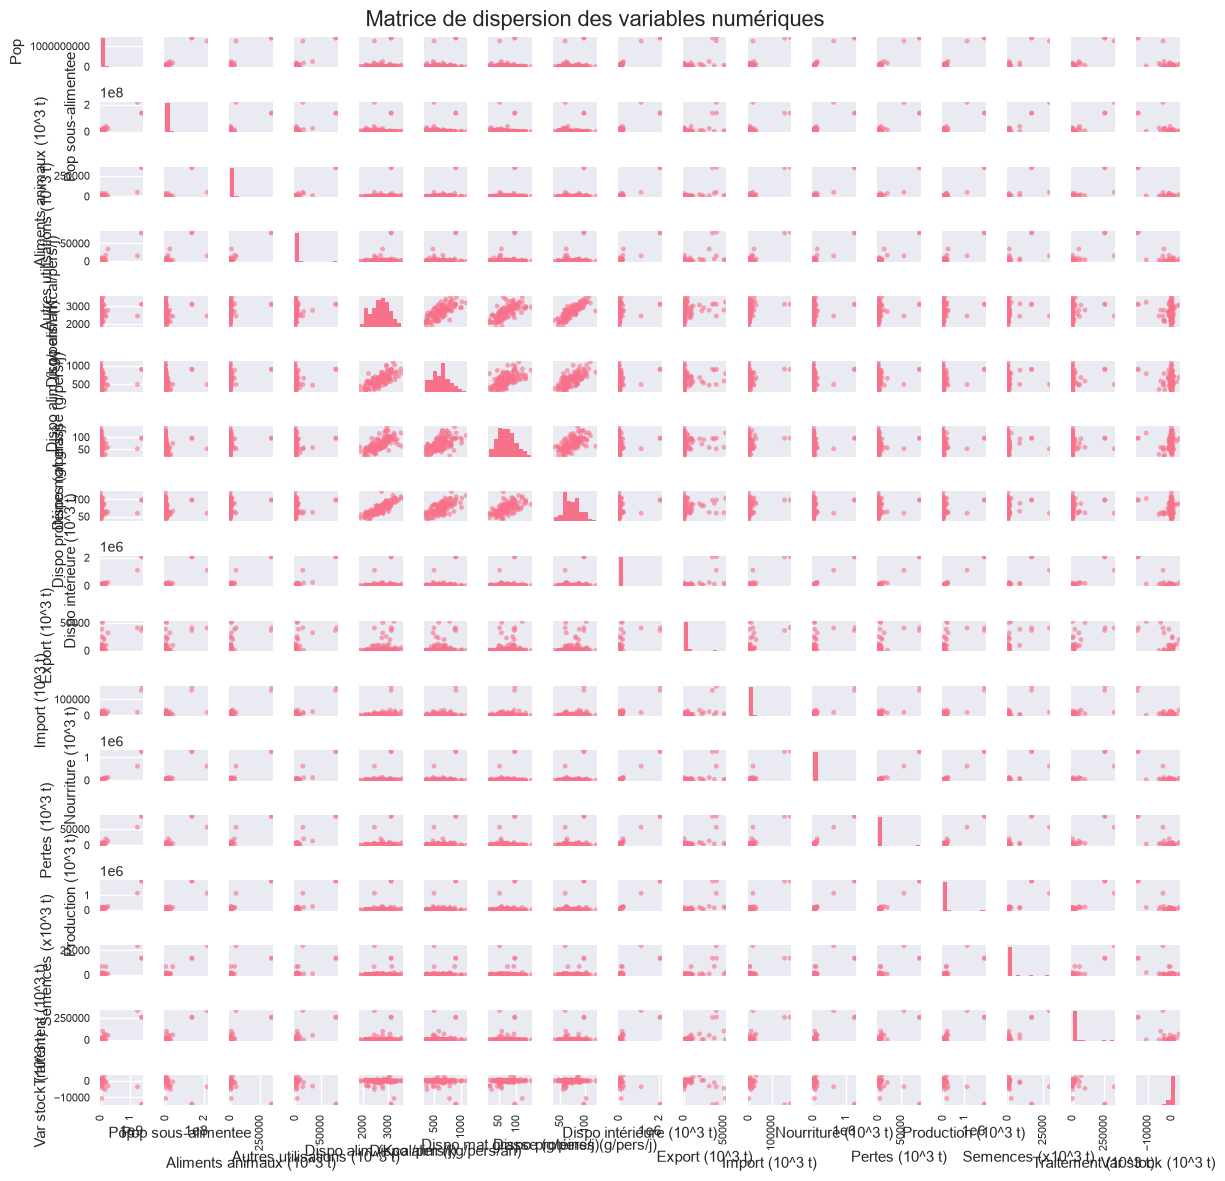


7. Création de la matrice de corrélation...


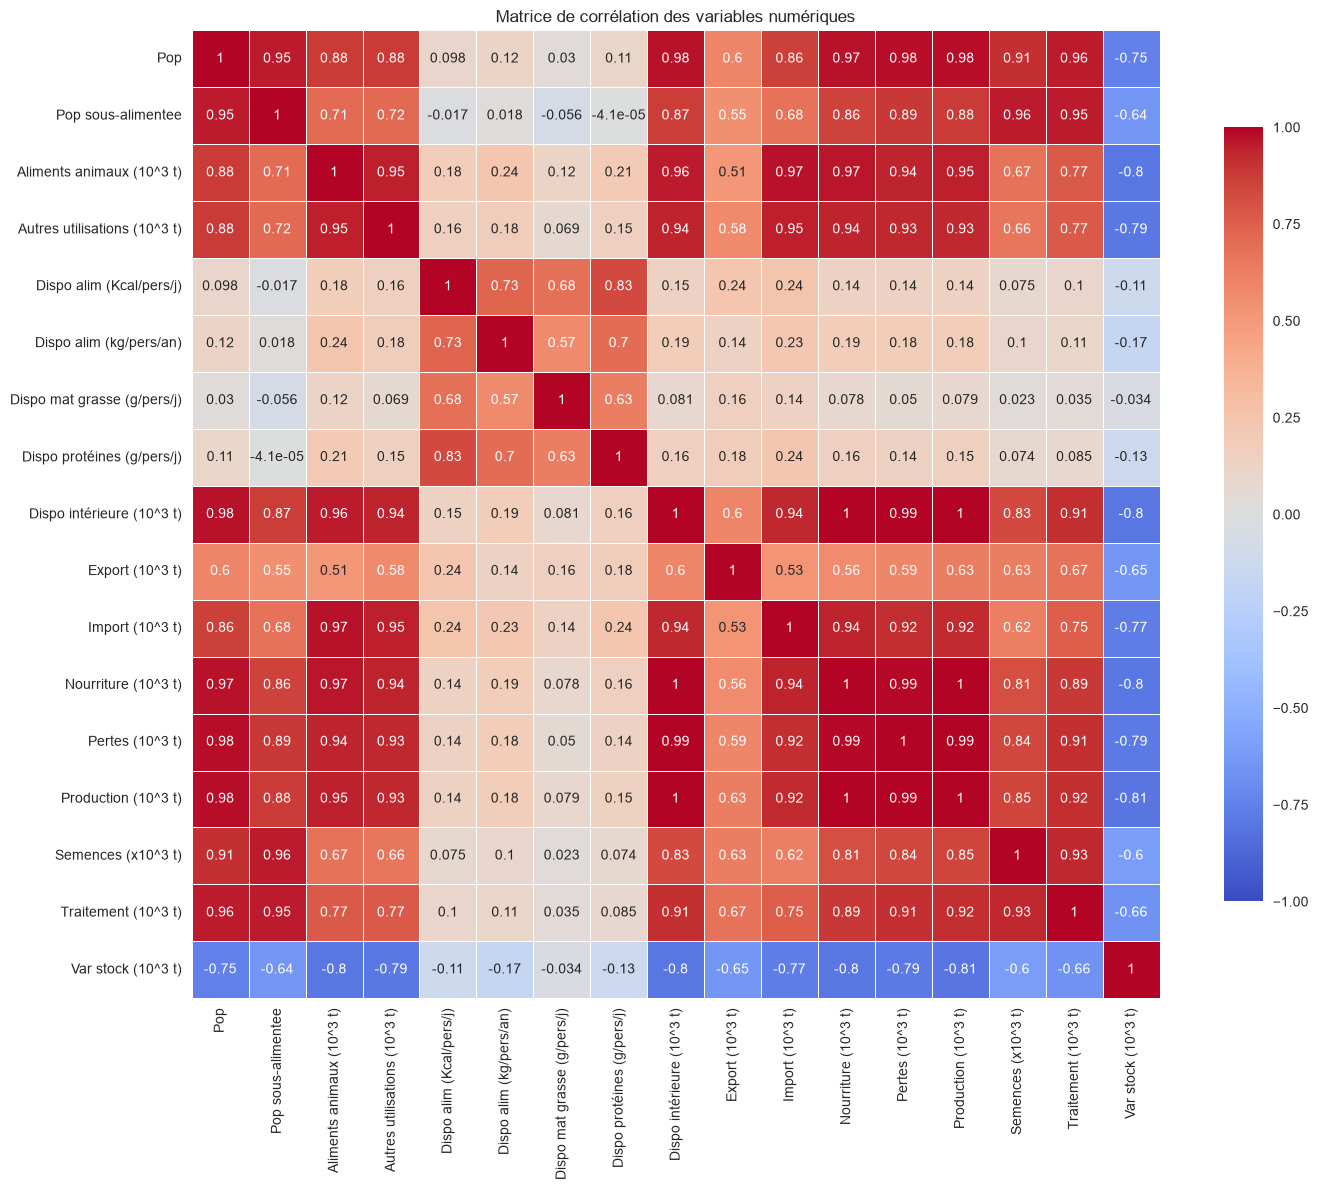


8. Création des répartitions...


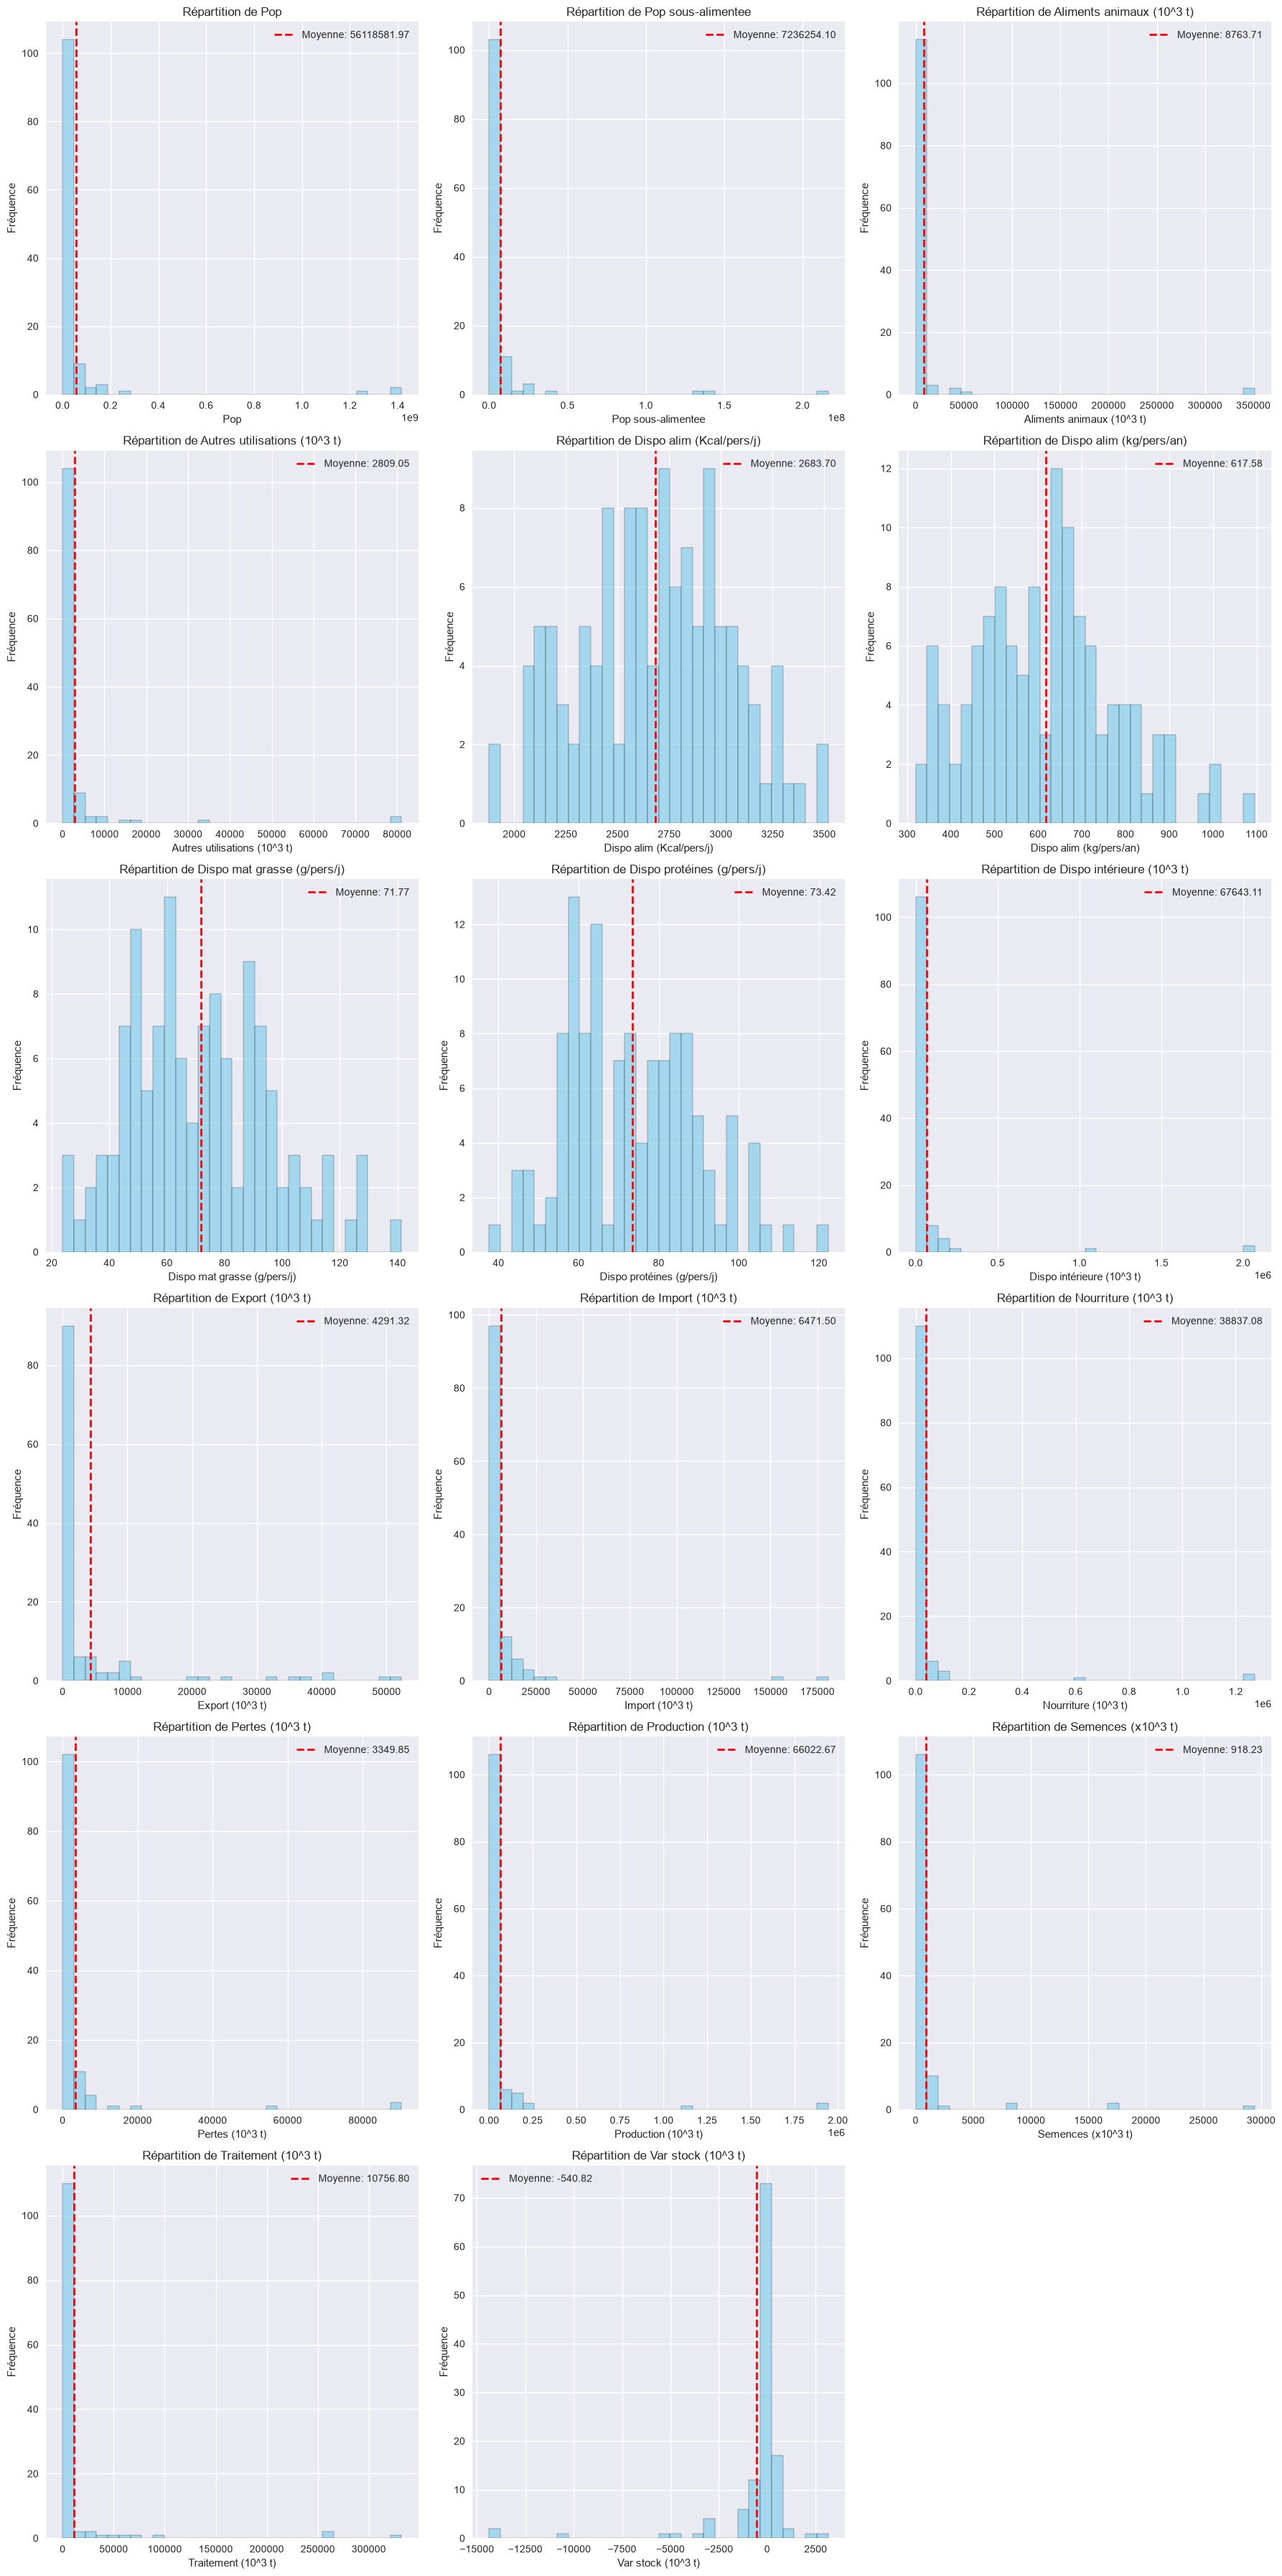


9. Corrélations significatives (|correlation| > 0.5):
             Variable 1                    Variable 2  Corrélation
0                   Pop            Pop sous-alimentee     0.953128
1                   Pop     Aliments animaux (10^3 t)     0.881534
2                   Pop  Autres utilisations (10^3 t)     0.881504
3                   Pop     Dispo intérieure (10^3 t)     0.976228
4                   Pop               Export (10^3 t)     0.600355
..                  ...                           ...          ...
79  Production (10^3 t)           Traitement (10^3 t)     0.919511
80  Production (10^3 t)            Var stock (10^3 t)    -0.808775
81   Semences (x10^3 t)           Traitement (10^3 t)     0.933819
82   Semences (x10^3 t)            Var stock (10^3 t)    -0.604782
83  Traitement (10^3 t)            Var stock (10^3 t)    -0.656251

[84 rows x 3 columns]
Script d'analyse exploratoire terminé.
Les fichiers suivants ont été générés:
- scatter_matrix.png
- correlation_heatm

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# je conserve intact le df_final et mais travailler sur df_analyses
df_analyses = df_final

# Configuration pour les visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def exploratory_data_analysis(df):
    """
    Fonction d'analyse exploratoire complète du dataframe
    """
    print("=== ANALYSE EXPLORATOIRE DU DATAFRAME ===")
    
    # Sélection des colonnes numériques (hors 'Code zone' et 'Zone')
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Suppression des colonnes spécifiques si elles existent
    columns_to_exclude = ['Code zone', 'Zone']
    for col in columns_to_exclude:
        if col in numeric_columns:
            numeric_columns.remove(col)
    
    print(f"\n5. Colonnes numériques utilisées pour l'analyse:")
    print(numeric_columns)
    
    # Matrice de dispersion
    print(f"\n6. Création de la matrice de dispersion...")
    
    # Sélection des colonnes numériques
    numeric_df = df[numeric_columns]
    
    # Matrice de dispersion (scatter matrix)
    plt.figure(figsize=(15, 12))
    pd.plotting.scatter_matrix(numeric_df, alpha=0.6, figsize=(12, 12), diagonal='hist')
    plt.suptitle('Matrice de dispersion des variables numériques', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Matrice de corrélation (heatmap)
    print(f"\n7. Création de la matrice de corrélation...")
    
    # Calcul de la matrice de corrélation
    correlation_matrix = numeric_df.corr()
    
    # Affichage du heatmap de corrélation
    plt.figure(figsize=(15, 12))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin = -1, vmax = 1,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Matrice de corrélation des variables numériques')
    plt.tight_layout()
    plt.show()
    
    # Répartitions (histogrammes)
    print(f"\n8. Création des répartitions...")
    
    # Calcul du nombre de sous-graphiques nécessaires
    n_cols = len(numeric_columns)
    n_rows = (n_cols + 2) // 3  # 3 colonnes par ligne
    
    # Création des histogrammes
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6*n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for i, col in enumerate(numeric_columns):
        axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Répartition de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Fréquence')
        
        # Ajout de statistiques
        mean_val = df[col].mean()
        std_val = df[col].std()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                       label=f'Moyenne: {mean_val:.2f}')
        axes[i].legend()
    
    # Cacher les axes vides
    for i in range(len(numeric_columns), len(axes)):
        axes[i].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # 9. Résumé des corrélations significatives
    print(f"\n9. Corrélations significatives (|correlation| > 0.5):")
    significant_correlations = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                significant_correlations.append({
                    'Variable 1': correlation_matrix.columns[i],
                    'Variable 2': correlation_matrix.columns[j],
                    'Corrélation': corr_val
                })
    
    if significant_correlations:
        corr_df = pd.DataFrame(significant_correlations)
        print(corr_df)
    else:
        print("Aucune corrélation significative trouvée (|r| > 0.5)")


exploratory_data_analysis(df_analyses)

print("Script d'analyse exploratoire terminé.")

En l'état, beaucoup de graphes sont peu lisibles  
Analysons la répartition, a t on besoin de tous ces indicateurs pour ce qui nous intéresse ?  
je vais supprimer les colonnes 'Semences (x10^3 t)', 'Traitement (x10^3 t)'
les colonnes Dispo intérieure Dispo et alim représente la même chose, je supprime 'Dispo alim (10^3 t)'
je vais créer la colonne 'pop sous_alimentee_pct' plus représentative en pourcentage qu'en nombre à la place de 'pop sous-alimentee' et 'pop'

In [984]:
# Création de la nouvelle colonne
df_analyses['Pop sous-alimentee pct'] = (df_analyses['Pop sous-alimentee'] / df_analyses['Pop']) * 100
    
# Suppression des colonnes inutiles
df_analyses = df_analyses.drop(['Pop', 'Pop sous-alimentee'], axis=1)
    
print("Modification du dataframe terminée !")
print(f"Nouvelles colonnes : {list(df_analyses.columns)}")
    

Modification du dataframe terminée !
Nouvelles colonnes : ['Code zone', 'Zone', 'Aliments animaux (10^3 t)', 'Autres utilisations (10^3 t)', 'Dispo alim (Kcal/pers/j)', 'Dispo alim (kg/pers/an)', 'Dispo mat grasse (g/pers/j)', 'Dispo protéines (g/pers/j)', 'Dispo intérieure (10^3 t)', 'Export (10^3 t)', 'Import (10^3 t)', 'Nourriture (10^3 t)', 'Pertes (10^3 t)', 'Production (10^3 t)', 'Semences (x10^3 t)', 'Traitement (10^3 t)', 'Var stock (10^3 t)', 'Pop sous-alimentee pct']


In [ ]:
colonnes_a_sup = ['Semences (x10^3 t)', 'Traitement (x10^3 t)', 'Dispo alim (10^3 t)']

    'Population': 'Pop',
    'Personnes sous-alimentées': 'Pop sous-alimentee',
    'Autres utilisations (non alimentaire)': 'Autres utilisations (10^3 t)',
    'Aliments pour animaux' : 'Aliments animaux (10^3 t)',
    'Disponibilité alimentaire (Kcal/personne/jour)' : 'Dispo alim (Kcal/pers/j)',
    'Disponibilité alimentaire en quantité (kg/personne/an)' : 'Dispo alim (kg/pers/an)',
    'Disponibilité de matière grasse en quantité (g/personne/jour)' : 'Dispo mat grasse (g/pers/j)',
    'Disponibilité de protéines en quantité (g/personne/jour)' : 'Dispo protéines (g/pers/j)',
    'Disponibilité intérieure' : 'Dispo intérieure (10^3 t)',
    'Exportations - Quantité' : 'Export (10^3 t)',
    'Importations - Quantité' : 'Import (10^3 t)',
    'Nourriture' : 'Nourriture (10^3 t)',
    'Pertes' : 'Pertes (10^3 t)',
    'Production' : 'Production (10^3 t)',
    'Semences' : 'Semences (x10^3 t)',
    'Traitement' : 'Traitement (10^3 t)',
    'Variation de stock' : 'Var stock (10^3 t)'